# Project Title: Cardiovascular Disease Prediction

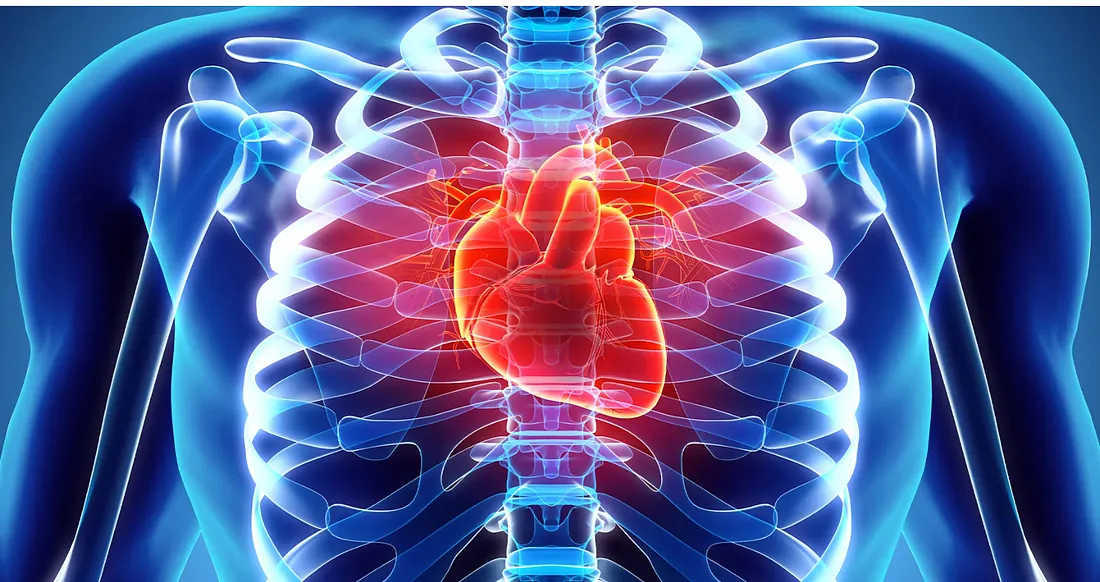

### Objective:

The aim of this project is to predict the occurrence of cardiovascular disease in patients based on their medical records.

### Description:

This project analyzes patients’ medical data and medical history to estimate the probability of developing cardiovascular disease. The analysis is based on the dataset CVD_cleaned.csv, which contains clinical, lifestyle, and demographic information about individuals. Machine learning techniques are applied to identify the factors most associated with cardiovascular disease risk.

### Dataset Overview:

The dataset contains multiple health and lifestyle-related features that may influence cardiovascular health.

#### Feature Description:

| Features | Description |
|----------|-------------|
| General Health | Overall health rating of the individual (e.g., Excellent, Very Good, Good, Fair, Poor). |
| Checkup | Frequency of medical checkups (e.g., Within last year, Within past two years, etc.). |
| Exercise | Information on physical activity levels. (Yes/No). |
| Heart Disease | Presence of heart disease (Yes/No). **(Target Variable)** |
| Skin Cancer | History of skin cancer (Yes/No). |
| Other Cancer | History of any cancer other than skin cancer (Yes/No). | 
| Depression | Indicator of depression (Yes/No). |
| Diabetes | Indicates if the individual has diabetes (Yes/No). |
| Arthritis |  Indicates if the individual has arthritis (Yes/No). |
| Sex | Gender of the patient. |
| Age Category | Age range category of the respondent. |
| Height (CM) | Height of the individual in centimeters. |
| Weight (KG) | Weight of the individual in kilograms. |
| BMI | Body Mass Index calculated from height and weight. |
| Smoking History | Smoking habits (Yes/No). |
| Alcohol Consumption | Quantity of alcohol consumption. |
| Fruit Consumption | Quantity of fruit consumption habits. |
| Green Vegetables Consumption | Quantity of green vegetable consumption. |
| Fried Potato Consumption | Quantity of fried potato consumption. |

This dataset provides a holistic view of factors that could influence the risk of developing cardiovascular diseases, allowing for detailed analysis and modeling to predict CVD risk.

### Importing Libraries

In [5]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load The Dataset

In [7]:
# Load the dataset
df = pd.read_csv('CVD_cleaned.csv')

In [8]:
# View the last five rows of the dataset
df.tail()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0
308853,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,45-49,160.0,81.19,31.71,No,1.0,5.0,12.0,1.0


### Data Preprocessing

In [10]:
# View the shape of the dataset
df.shape

(308854, 19)

The dataset consists of 308,854 rows and 19 columns.

* Each row represents an individual patient record.
* Each column represents a specific feature or variable related to the patient's health or lifestyle.

In [12]:
# View the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

* The dataset has 19 features — 12 categorical (object) and 7 numerical (float64).
* There are no missing values, as all columns contain 308,854 non-null entries.
* The total memory usage of the dataset is approximately 44.8 MB
* The features include health indicators (e.g., BMI, Diabetes, Depression), lifestyle factors (e.g., Smoking_History, Exercise), and demographic attributes (e.g., Age_Category, Sex).

### Handling Duplicate Records

Duplicate records can negatively affect the accuracy and reliability of the model. Therefore, it is important to identify and remove them before further analysis.

In [15]:
# Shape of the dataset before dropping duplicates
print("Shape of the dataset before dropping duplicates:", df.shape)

# Checking Duplicates before dropping
print("Number of duplicates records in the dataset:", df.duplicated().sum())

Shape of the dataset before dropping duplicates: (308854, 19)
Duplicates records in the dataset before dropping: 80


In [16]:
# Dropping Duplicates Records
df = df.drop_duplicates()

# Checking Duplicates after dropping
print("Duplicates records in the dataset after dropping:", df.duplicated().sum())

# Shape of the dataset after dropping duplicates
print("Shape of the dataset after dropping duplicates:", df.shape)

Duplicates records in the dataset after dropping: 0
Shape of the dataset after dropping duplicates: (308774, 19)


* The dataset initially contained 308,854 rows and 19 columns, out of which 80 records were identified as duplicates. These duplicate records needed to be removed to ensure data quality and prevent bias during model training.
* **df = df.drop_duplicates()** This command removes all duplicate rows from the dataset, keeping only the first occurrence of each record.
* After removing duplicates:
  * The total number of records reduced from 308,854 to 308,774, confirming that 80 duplicate records were successfully removed.
  * The dataset now contains 308,774 unique records and 19 columns, ensuring data integrity for subsequent analysis.

### Checking Missing Values

In [19]:
# Check the missing values in the dataset
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

There are no missing values in the dataset. 

### Dropping Redundant Features: Height and Weight

The dataset contains the columns Weight, Height, and BMI. However, since the BMI column is calculated using the weight and height values, the Weight and Height columns were dropped from the dataset to remove redundancy.

In [22]:
# Drop columns Weight and Height
df.drop(columns = ['Weight_(kg)', 'Height_(cm)'], inplace = True)

In [23]:
# Check the columns after dropping Weight and Height columns
df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'BMI', 'Smoking_History', 'Alcohol_Consumption',
       'Fruit_Consumption', 'Green_Vegetables_Consumption',
       'FriedPotato_Consumption'],
      dtype='object')

In [24]:
# Statistical Summary of the dataset before removing outliers
df.describe()

,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000
mean,28.626813,5.097557,29.834290,15.109517,6.297237
std,6.522810,8.200434,24.877812,14.926912,8.583837
min,12.020000,0.000000,0.000000,0.000000,0.000000
25%,24.210000,0.000000,12.000000,4.000000,2.000000
50%,27.440000,1.000000,30.000000,12.000000,4.000000
75%,31.850000,6.000000,30.000000,20.000000,8.000000
max,99.330000,30.000000,120.000000,128.000000,128.000000


### Outlier Removal

In [26]:
# List of columns to check for outliers
cols = ['BMI', 'Alcohol_Consumption', 'Fruit_Consumption',
        'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

# Create a dictionary to store the outlier summary
outlier_summary = {}

# Calculate outliers for each column
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
        
# Display the summary as a DataFrame
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['Column', 'Outlier_Count'])
print(outlier_df)

# Define threshold
threshold = 1.5

# Calculate Q1, Q3, and IQR for ALL numeric columns together
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

# Save original shape
original_shape = df.shape

# Keep only non-outlier rows across all selected columns
df = df[~((df[cols] < (Q1 - threshold * IQR)) | 
          (df[cols] > (Q3 + threshold * IQR))).any(axis=1)]

# Reset index for clean numbering
df = df.reset_index(drop=True)

# Print results
print("\nShape before removing outliers (Original Dataset Shape):", original_shape)
print("Dataset Shape after removing outliers:", df.shape)

                         Column  Outlier_Count
0                           BMI           9530
1           Alcohol_Consumption          36147
2             Fruit_Consumption          68212
3  Green_Vegetables_Consumption          11877
4       FriedPotato_Consumption          19456

Shape before removing outliers (Original Dataset Shape): (308774, 17)
Dataset Shape after removing outliers: (186711, 17)


In [27]:
# Statistical Summary after removing outlier
df.describe()

,BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,186711.000000,186711.000000,186711.000000,186711.000000,186711.000000
mean,28.304300,2.506007,18.442834,11.891603,4.899958
std,5.434217,3.777366,10.898306,9.604113,4.262223
min,12.870000,0.000000,0.000000,0.000000,0.000000
25%,24.370000,0.000000,8.000000,4.000000,2.000000
50%,27.550000,0.000000,16.000000,8.000000,4.000000
75%,31.750000,4.000000,30.000000,16.000000,8.000000
max,43.280000,15.000000,56.000000,44.000000,17.000000


#### Outlier Detection and Removal (Summary)

The dataset contains numeric features — BMI, Alcohol_Consumption, Fruit_Consumption, Green_Vegetables_Consumption, and FriedPotato_Consumption — which were analyzed for outliers.

* Before Outlier Removal: The features exhibited wide value ranges, e.g., BMI ranged from 12.02 to 99.33 and Fruit_Consumption from 0 to 120, indicating potential extreme values.
* Outlier Detection: Using the Interquartile Range (IQR) method, outliers were identified as values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.
   
   | Column | Outlier Count |
   |--------|---------------|
   | BMI | 9530 |
   | Alcohol_Consumption | 36147 |
   | Fruit_Consumption | 68212 |
   | Green_Vegetables_Consumption | 11877 |
   | FriedPotato_Consumption | 19456 |
  
* Outlier Removal: Records with outliers in any of the selected features were removed.
* After Outlier Removal: The dataset shows reduced mean and standard deviation for all features, and extreme values were capped (e.g., BMI max reduced from 99.33 → 43.28, Fruit_Consumption max from 120 → 56).

The cleaned dataset is more consistent and representative of the general population, making it suitable for reliable predictive modeling

In [29]:
# Recheck the last five rows of the dataset
df.tail()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
186706,Good,Within the past 5 years,Yes,No,No,No,No,No,No,Male,55-59,20.98,No,0.0,16.0,12.0,0.0
186707,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,29.05,No,4.0,30.0,8.0,0.0
186708,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,24.69,Yes,4.0,40.0,8.0,4.0
186709,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,23.73,No,3.0,30.0,12.0,0.0
186710,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,45-49,31.71,No,1.0,5.0,12.0,1.0


### Exploratory Data Analysis

In this section, I will perform exploratory data analysis to better understand the dataset. I will examine the distribution of all variables and explore the relationships between the features and the target variable. This analysis will help identify patterns, trends, and potential correlations that could be important for predictive modeling.

### Patient Demographics

patient demographics generally refer to the personal characteristics of the patient, such as age, gender, and sometimes general health or lifestyle indicators that are intrinsic to the individual rather than medical history or behaviors.

1. Sex - Gender of the patient
2. Age_Category - Age group of the patient
3. BMI - 

### Sex Distribution 

In [33]:
# Get the unique values for Sex in the dataset
print("Types of Sex in the dataset:", df['Sex'].unique())

# Get the value count for each sex
print("\nCount for each sex in the dataset:", df['Sex'].value_counts())

# Get the percentage count for each sex in the dataset
print("\nCount for each sex in the dataset:", df['Sex'].value_counts(normalize = True) * 100)

Types of Sex in the dataset: ['Female' 'Male']

Count for each sex in the dataset: Sex
Female    96486
Male      90225
Name: count, dtype: int64

Count for each sex in the dataset: Sex
Female    51.676655
Male      48.323345
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Sex Distribution')

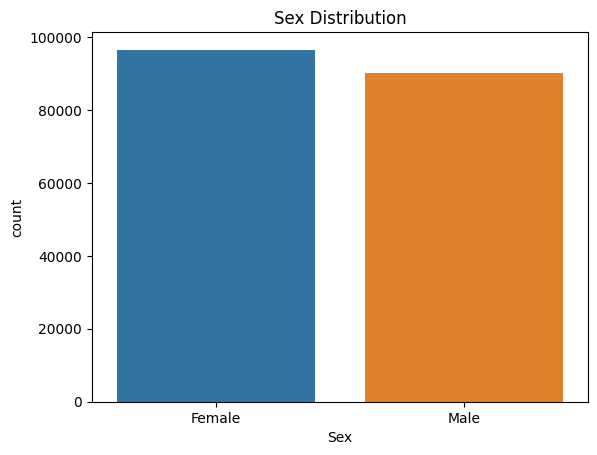

In [34]:
# Plot a bar graph for sex distribution 
sns.countplot(x = 'Sex', data = df).set_title('Sex Distribution')

#### Analysis of Patient Gender

The Sex column in the dataset contains two unique values: Female and Male. The distribution of patients by gender is as follows:
* Female: 96,486 patients (≈ 51.68%)
* Male: 90,225 patients (≈ 48.32%)

This shows that the dataset is relatively balanced in terms of gender, with a slightly higher proportion of female patients.

### Age Category Distribution

In [37]:
# Get the unique values for age category in the dataset
print("Types of age category in the dataset:", df['Age_Category'].unique())

# Get the value count for each age category
print("\nCount for each age category in the dataset:", df['Age_Category'].value_counts())

# Get the percentage count for each age category in the dataset
print("\nCount for each Age Category in the dataset:", df['Age_Category'].value_counts(normalize = True) * 100)

Types of age category in the dataset: ['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '30-34' '55-59'
 '18-24' '35-39' '40-44' '25-29']

Count for each age category in the dataset: Age_Category
65-69    19936
60-64    19445
70-74    18860
55-59    16859
50-54    15083
80+      13840
75-79    12573
45-49    12530
40-44    12453
18-24    12335
35-39    12014
30-34    11063
25-29     9720
Name: count, dtype: int64

Count for each Age Category in the dataset: Age_Category
65-69    10.677464
60-64    10.414491
70-74    10.101172
55-59     9.029463
50-54     8.078260
80+       7.412525
75-79     6.733936
45-49     6.710906
40-44     6.669666
18-24     6.606467
35-39     6.434543
30-34     5.925200
25-29     5.205906
Name: proportion, dtype: float64


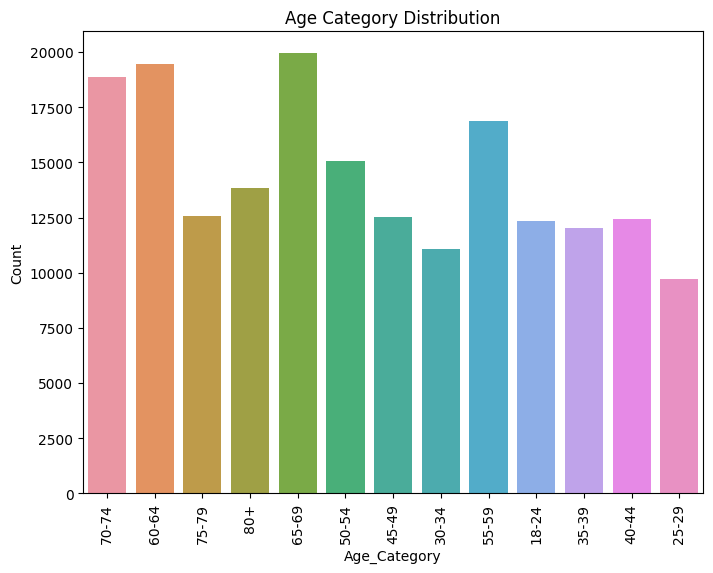

In [38]:
# Plot a bar graph for age category distribution 
plt.figure(figsize = (8, 6))
sns.countplot(x = 'Age_Category', data = df)
plt.title('Age Category Distribution')
plt.xlabel = ('Age Category')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.show()

#### Analysis of Patient Age Categories

The Age_Category column contains 13 distinct age groups ranging from 18-24 to 80+. The distribution of patients across these age categories is as follows:

| Age Category | Count | Percentage (%) |
|--------------|-------|----------------|
| 65 - 69 | 19,936 | 10.68 |
| 60 - 64 | 19,445 | 10.41 |
| 70 - 74 | 18,860 | 10.10 |
| 55 - 59 | 16,859 | 9.03 |
| 50 - 54 | 15,083 | 8.08 |
| 80 + | 13,840 | 7.41 |
| 75 - 79 | 12,573 | 6.73 |
| 45 - 49 | 12,530 | 6.71 |
| 40 - 44 | 12,453 | 6.67 |
| 18 - 24 | 12,335 | 6.61 |
| 35 - 39 | 12,014 | 6.43 |
| 30 - 34 | 11,063 | 5.93 |
| 25 - 29 | 9,720 | 5.21 |

The most represented age group in the dataset is 65-69 years (≈10.68%), while the least represented is 25-29 years (≈5.21%). Overall, the dataset has a higher concentration of middle-aged and older adults, which is typical for studies related to cardiovascular disease.

### BMI Distribution

In [41]:
# Get the unique values for BMI in the dataset
print("BMI distribution in the dataset:", df['BMI'].unique())

# Get the value count for each BMI
print("\nCount for each BMI in the dataset:", df['BMI'].value_counts())

BMI distribution in the dataset: [14.54 28.29 33.47 ... 31.98 18.34 19.09]

Count for each BMI in the dataset: BMI
26.63    2027
27.46    1672
27.44    1643
24.41    1499
27.12    1359
         ... 
34.43       1
15.18       1
26.51       1
23.77       1
19.09       1
Name: count, Length: 2337, dtype: int64


C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'BMI Distribution')

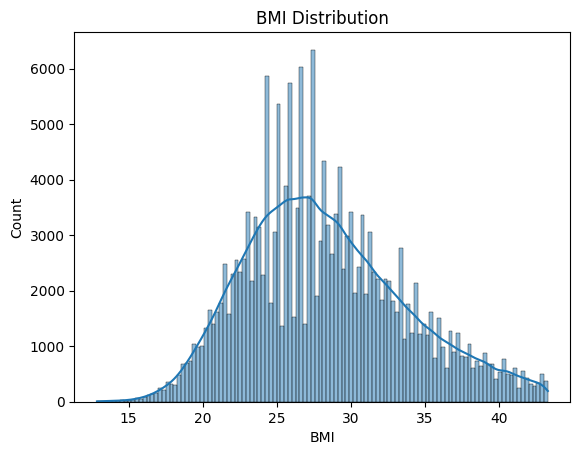

In [42]:
# Plot a histogram for BMI distribution
sns.histplot(x = 'BMI', data = df, kde = True).set_title('BMI Distribution')

The histogram of BMI shows that the BMI of majority of patients is between 25 to 30. This means that majority of patients are overweight. Therefore, I build a hypothesis that the patients with higher BMI are more likely to have cardiovascular disease.

In [44]:
df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'BMI', 'Smoking_History', 'Alcohol_Consumption',
       'Fruit_Consumption', 'Green_Vegetables_Consumption',
       'FriedPotato_Consumption'],
      dtype='object')

### General_Health

In [46]:
# Get the unique values for General Health in the dataset
print("Types of general health in the dataset:", df['General_Health'].unique())

# Get the value count for each general health
print("\nCount for each general health in the dataset:", df['General_Health'].value_counts())

# Get the percentage count for each general health in the dataset
print("\nCount for each general health in the dataset:", df['General_Health'].value_counts(normalize = True) * 100)

Types of general health in the dataset: ['Poor' 'Very Good' 'Good' 'Fair' 'Excellent']

Count for each general health in the dataset: General_Health
Very Good    66009
Good         59730
Excellent    31202
Fair         22655
Poor          7115
Name: count, dtype: int64

Count for each general health in the dataset: General_Health
Very Good    35.353568
Good         31.990617
Excellent    16.711388
Fair         12.133725
Poor          3.810702
Name: proportion, dtype: float64


Text(0.5, 1.0, 'General Health Distribution')

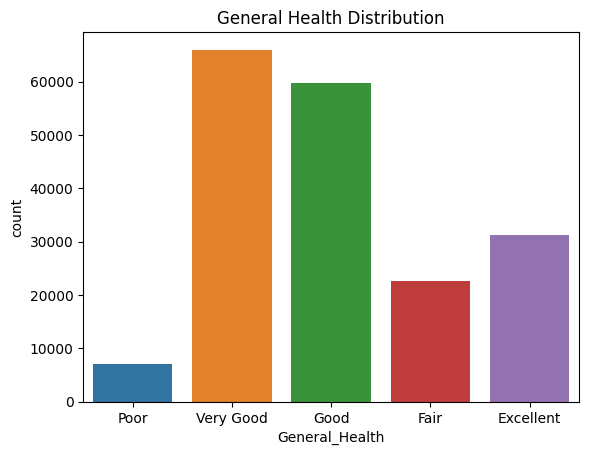

In [47]:
# Plot a bar graph for general health
sns.countplot(x = 'General_Health', data = df).set_title('General Health Distribution')

#### General Health Analysis

The General_Health column represents the self-reported overall health condition of patients.

* Unique Categories: The dataset contains five categories: Poor, Fair, Good, Very Good, and Excellent.
* Frequency of Each Category:
  * Very Good: 66,009 patients (≈35.35%)
  * Good: 59,730 patients (≈31.99%)
  * Excellent: 31,202 patients (≈16.71%)
  * Fair: 22,655 patients (≈12.13%)
  * Poor: 7,115 patients (≈3.81%)
* Observation: The majority of patients report their health as "Very Good" or "Good," which together account for over 67% of the population. Only a small proportion (≈3.8%) reported "Poor" health. This indicates that most patients perceive their general health positively, with fewer individuals in the extreme lower health category.

### Checkup

In [50]:
# Get the unique values for Checkup in the dataset
print("Types of Checkup in the dataset:", df['Checkup'].unique())

# Get the value count for each Checkup
print("\nCount for each Checkup in the dataset:", df['Checkup'].value_counts())

# Get the percentage count for each Checkup in the dataset
print("\nCount for each Checkup in the dataset:", df['Checkup'].value_counts(normalize = True) * 100)

Types of Checkup in the dataset: ['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']

Count for each Checkup in the dataset: Checkup
Within the past year       144967
Within the past 2 years     22407
Within the past 5 years     10536
5 or more years ago          7925
Never                         876
Name: count, dtype: int64

Count for each Checkup in the dataset: Checkup
Within the past year       77.642453
Within the past 2 years    12.000900
Within the past 5 years     5.642946
5 or more years ago         4.244528
Never                       0.469174
Name: proportion, dtype: float64


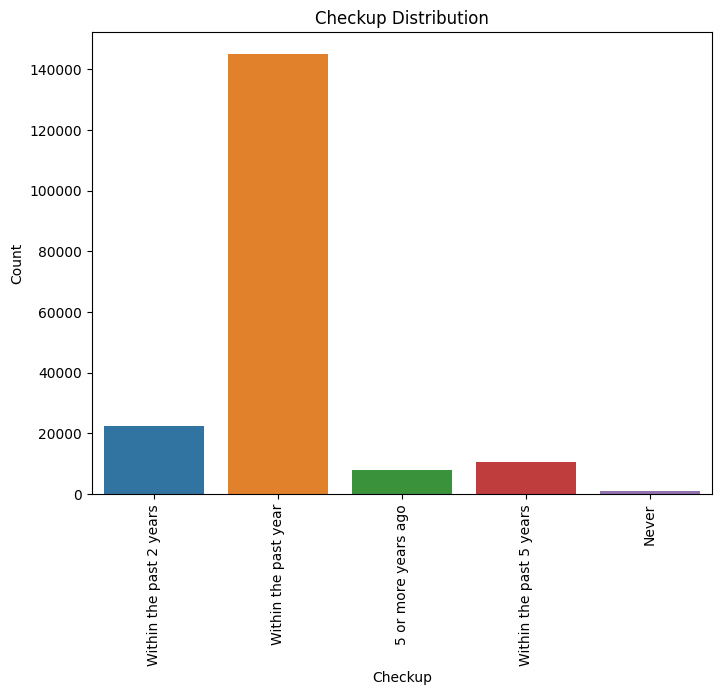

In [51]:
# Plot a bar graph for Checkup
plt.figure(figsize = (8, 6))
sns.countplot(x = 'Checkup', data = df)
plt.title('Checkup Distribution')
plt.xlabel = ('Checkup')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.show()

#### Analysis of Checkup Frequency in the Dataset

The dataset contains information about the frequency of routine medical checkups for patients. The unique categories for Checkup are:

| Checkup Category | Count | Percentage (%) |
|------------------|-------|----------------|
| Within the past year | 144,967 | 77.64 |
| Within the past 2 years | 22,407 | 12.00 |
| Within the past 5 years | 10,536 | 5.64 |
| 5 or more years ago | 7,925 | 4.24 |
| never | 876 | 0.47 |

* The majority of patients (77.64%) reported having a checkup within the past year, indicating regular health monitoring.
* Very few patients (0.47%) reported never having a medical checkup, which might indicate either good healthcare access or underreporting.
* The remaining categories show a gradual decrease in frequency as the time since the last checkup increases.

This distribution highlights that most patients in the dataset are proactive about their routine health checkups, but a small proportion may be at risk due to infrequent or no checkups.

### General Health and Checkup

In [54]:
# Crosstab for counts
checkup_vs_health_count = pd.crosstab(df['General_Health'], df['Checkup'])
print("Counts for General Health vs Checkup:")
print(checkup_vs_health_count)

# Crosstab for percentages
checkup_vs_health_percent = pd.crosstab(df['General_Health'], df['Checkup'], normalize='index') * 100
print("\nPercentage distribution for General Health vs Checkup:")
print(checkup_vs_health_percent.round(2))

Counts for General Health vs Checkup:
Checkup         5 or more years ago  Never  Within the past 2 years  \
General_Health                                                        
Excellent                      1951    236                     4799   
Fair                            706    110                     1894   
Good                           2298    256                     6637   
Poor                            153     30                      496   
Very Good                      2817    244                     8581   

Checkup         Within the past 5 years  Within the past year  
General_Health                                                 
Excellent                          2357                 21859  
Fair                                870                 19075  
Good                               3104                 47435  
Poor                                177                  6259  
Very Good                          4028                 50339  

Percentage dist

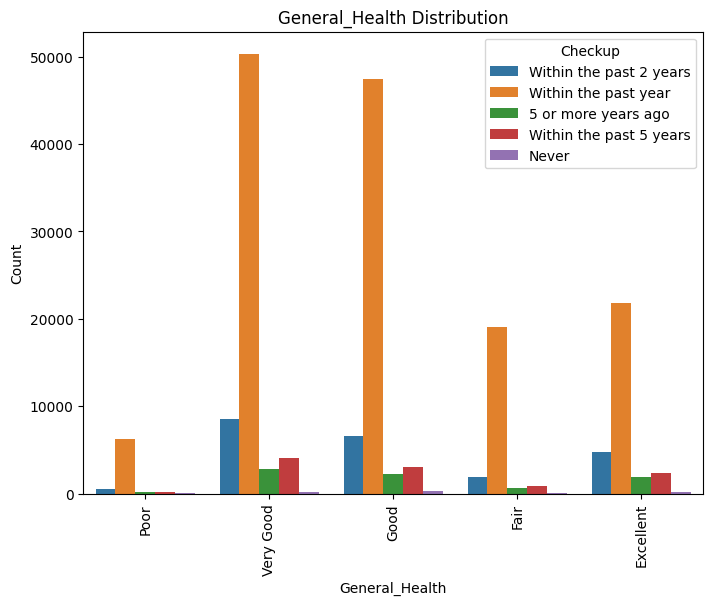

In [55]:
# Plot a bar graph for Checkup
plt.figure(figsize = (8, 6))
sns.countplot(x = 'General_Health', hue = 'Checkup', data = df)
plt.title('General_Health Distribution')
plt.xlabel = ('Checkup')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.show()

##### Analysis of General Health vs Checkup Frequency

This analysis explores the relationship between patients’ self-reported general health and the frequency of their routine medical checkups. The dataset allows us to see both counts and percentage distribution for each combination of general health status and checkup category.

| General Health | 5 or more years ago | Never | Within the past 2 years | Within the past 5 years | Within the past year | 
|----------------|---------------------|-------|-------------------------|-------------------------|----------------------|
| Excellent | 1,951 (6.25%) | 236 (0.76%) | 4,799 (15.38%) | 2,357 (7.55%)| 21,859 (70.06%) |
| Fair | 706 (3.12%) | 110 (0.49%) | 1,894 (8.36%) | 870 (3.84%) | 19,075 (84.20%) |
| Good | 2,298 (3.85%) | 256 (0.43%) | 6,637 (11.11%) | 3,104 (5.20%) | 47,435 (79.42%) |
| Poor | 153 (2.15%) | 30 (0.42%) | 496 (6.97%) | 177 (2.49%) | 6,259 (87.97%) |
| Very Good | 2,817 (4.27%) | 244 (0.37%) | 8,581 (13.00%) | 4,028 (6.10%) | 50,339 (76.26%) |

1. Frequent Checkups in Good Health:
   * Patients reporting “Excellent” or “Very Good” health predominantly had checkups within the past year (70.06% and 76.26%, respectively), suggesting proactive health monitoring.
2. Poor Health and Infrequent Checkups:
   * Interestingly, patients reporting “Poor” health also show a high proportion (87.97%) of checkups within the past year, indicating that sicker individuals may have more frequent medical visits.
3. Low Checkup Frequency:
   * Across all health categories, very few patients reported never having a checkup (0.37%–0.76%), highlighting good overall healthcare access in this population.
4. Moderate Time Gaps:
   * Categories like “Within the past 2 years” and “Within the past 5 years” represent smaller percentages, suggesting that only a minority of patients delay routine checkups.
  
The dataset indicates a strong association between general health perception and checkup frequency. Most patients, irrespective of health status, tend to have routine checkups within the past year, though the proportion is slightly higher among those with poorer health. This insight can inform preventive care strategies and targeted health interventions.

### Exercise

In [58]:
# Get the unique values for Exercise
print("Types of exercise in the dataset:", df['Exercise'].unique())

# Get the value counts for Exercise
print("\nExercise counts in the dataset:", df['Exercise'].value_counts())

# Get the percenatge for Exercise
print("\nPercentage of Exercise in the dataset:", df['Exercise'].value_counts(normalize = True) * 100)

Types of exercise in the dataset: ['No' 'Yes']

Exercise counts in the dataset: Exercise
Yes    140810
No      45901
Name: count, dtype: int64

Percentage of Exercise in the dataset: Exercise
Yes    75.416017
No     24.583983
Name: proportion, dtype: float64


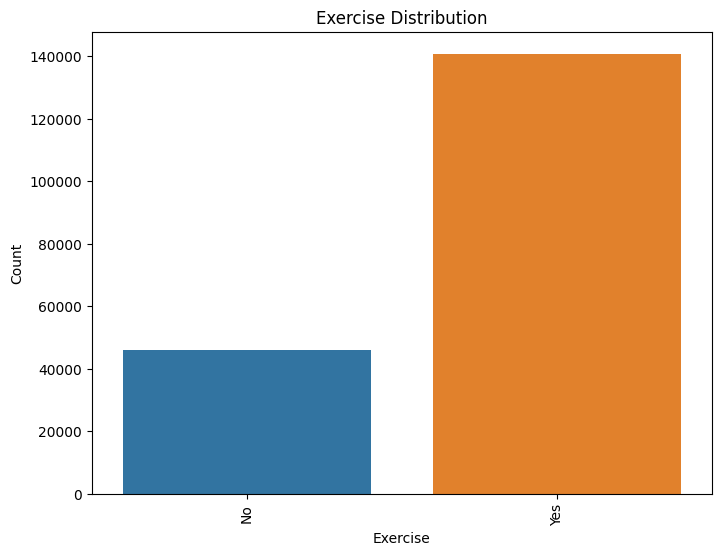

In [59]:
# Plot the bar graph for exercise
plt.figure(figsize=(8,6))
sns.countplot(x = 'Exercise', data = df)
plt.title('Exercise Distribution')
plt.xlabel = ('Exercise')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.show()

##### Exercise Distribution in the Dataset

The dataset includes information about whether participants engage in regular exercise, with two possible values: Yes and No. 

| Exercise | Count | Percentage |
| Yes | 140,810 | 75.42 |
| No | 45901 | 24.58 |

The majority of participants (around three-quarters) reported engaging in regular exercise, while about one-quarter of the participants do not exercise regularly. This indicates that physical activity is common among the study population.

### Exercise and General Health

In [62]:
# Crosstab for exercise and general health counts
exercise_vs_health_count = pd.crosstab(df['General_Health'], df['Exercise'])
print("Counts for General Health vs Exercise:")
print(exercise_vs_health_count)

# Crosstab for exercise and general health percentage distribution
exercise_vs_health_percent = pd.crosstab(df['General_Health'], df['Exercise'], normalize='index') * 100
print("\nPercentage distribution for General Health vs Exercise:")
print(exercise_vs_health_percent.round(2))

Counts for General Health vs Exercise:
Exercise           No    Yes
General_Health              
Excellent        4175  27027
Fair             9940  12715
Good            16393  43337
Poor             4382   2733
Very Good       11011  54998

Percentage distribution for General Health vs Exercise:
Exercise           No    Yes
General_Health              
Excellent       13.38  86.62
Fair            43.88  56.12
Good            27.45  72.55
Poor            61.59  38.41
Very Good       16.68  83.32


Text(0.5, 1.0, 'General health and Exercise')

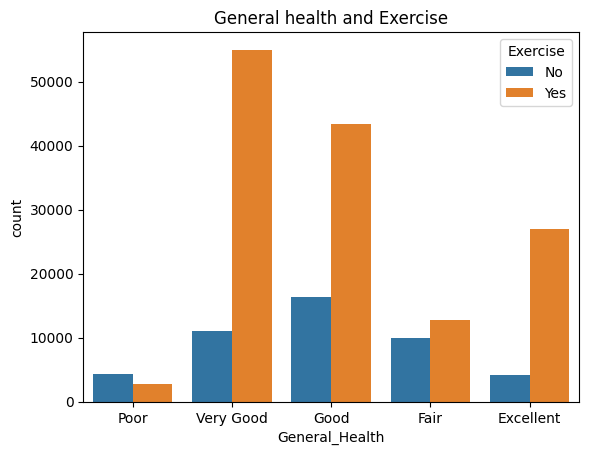

In [63]:
# Plot a graph for general health and exercise
sns.countplot(x = 'General_Health', hue = 'Exercise', data = df).set_title('General health and Exercise')

##### Exercise Patterns by General Health

The analysis explores the relationship between participants’ general health status and their exercise habits. The results are summarized below:

| General Health | Exercise (No) | Exercise (Yes) |
|----------------|---------------|----------------|
| Excellent | 4175 (13.38%) | 27027 (86.62%) | 
| Fair | 9940 (43.88%) | 12715 (56.12%) |
| Good | 16393 (27.45%) | 43337 (72.55%) |
| Poor | 4382 (61.59%) | 2733 (38.41%) |
| Very Good | 11011 (16.68%) | 54998 (83.32%) |

The relationship between general health status and exercise habits reveals a clear trend in the dataset. Among individuals reporting “Excellent” health, a significant majority (86.62%) engage in regular exercise, while only 13.38% do not. Similarly, 83.32% of those with “Very Good” health and 72.55% with “Good” health reported exercising. In contrast, the proportion of individuals who do not exercise increases as self-reported health declines — 43.88% of those with “Fair” health and as high as 61.59% among those with “Poor” health reported not engaging in physical activity.

This pattern clearly indicates a positive correlation between exercise frequency and perceived general health. Individuals who maintain regular exercise habits tend to rate their health as good or excellent, whereas those with poorer health are less likely to exercise regularly.

### Food Consumption

1. Alcohol_Consumption
2. Fruit_Consumption
3. Green_Vegetables_Consumption
4. FriedPotato_Consumption

### Alcohol_Consumption

In [67]:
# Get the unique values for alcohol consumption
print("Alcohol consumption in the dataset:", df['Alcohol_Consumption'].value_counts())

# Get the unique values for alcohol consumption
print("\nPercentage of alcohol consumption:", df['Alcohol_Consumption'].value_counts(normalize = True) * 100)

Alcohol consumption in the dataset: Alcohol_Consumption
0.0     95253
1.0     17108
4.0     16108
2.0     13561
8.0      9108
3.0      7921
5.0      6783
12.0     5999
10.0     5541
15.0     4415
6.0      2474
7.0      1853
14.0      342
9.0       166
13.0       53
11.0       26
Name: count, dtype: int64

Percentage of alcohol consumption: Alcohol_Consumption
0.0     51.016276
1.0      9.162824
4.0      8.627237
2.0      7.263096
8.0      4.878127
3.0      4.242385
5.0      3.632887
12.0     3.212987
10.0     2.967688
15.0     2.364617
6.0      1.325042
7.0      0.992443
14.0     0.183171
9.0      0.088907
13.0     0.028386
11.0     0.013925
Name: proportion, dtype: float64


C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Alcohol Consumption Distribution')

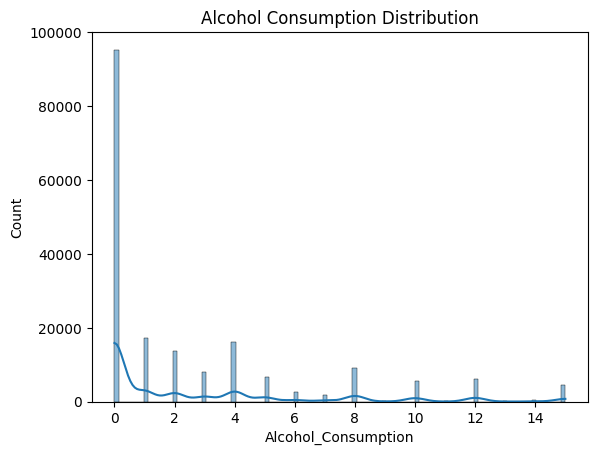

In [68]:
# Plot a graph for alcohol consumption
sns.histplot(x = 'Alcohol_Consumption', data = df, kde = True).set_title('Alcohol Consumption Distribution')

#### Alcohol Consumption Analysis

The dataset records various levels of alcohol consumption among respondents, measured in frequency units. The distribution of alcohol consumption levels shows substantial variation across the population.
* The majority of respondents (51.02%) reported an alcohol consumption value of 0, indicating that more than half of the participants do not consume alcohol.
* The next most common consumption frequencies were 1.0 (9.16%), 4.0 (8.63%), and 2.0 (7.26%), suggesting that occasional or low-frequency drinking is relatively common.
* Moderate consumption levels such as 8.0 (4.88%), 3.0 (4.24%), and 5.0 (3.63%) were reported by smaller proportions of respondents.
* Higher alcohol consumption levels such as 10.0 (2.97%), 12.0 (3.21%), and 15.0 (2.36%) were much less frequent, indicating that heavy drinking is relatively uncommon in this sample.
* Extremely high values (≥13.0) are rare, collectively accounting for less than 1% of the dataset.

Overall, the alcohol consumption data is right-skewed, dominated by individuals reporting **zero or low consumption**, with a gradual decline in frequency as consumption levels increase. This indicates that while alcohol use is present in the dataset, abstainers and light drinkers form the majority of the surveyed population.

### Fruit_Consumption

In [71]:
# Get the unique values for alcohol consumption
print("Fruit consumption in the dataset:", df['Fruit_Consumption'].value_counts())

# Get the unique values for alcohol consumption
print("\nPercentage of fruit consumption:", df['Fruit_Consumption'].value_counts(normalize = True) * 100)

Fruit consumption in the dataset: Fruit_Consumption
30.0    70762
12.0    24111
8.0     17815
16.0    13765
20.0    13311
4.0     10775
0.0      5914
2.0      4345
5.0      3816
3.0      3536
10.0     3249
15.0     2943
28.0     2629
1.0      2560
24.0     1842
40.0     1318
6.0      1269
25.0      822
7.0       667
32.0      240
14.0      173
48.0      103
56.0       82
45.0       78
9.0        71
18.0       62
36.0       57
50.0       49
22.0       39
21.0       38
27.0       35
31.0       35
17.0       33
26.0       24
13.0       24
35.0       22
44.0       19
29.0       18
11.0       17
23.0       14
33.0       13
19.0        5
55.0        3
52.0        3
39.0        2
38.0        1
42.0        1
34.0        1
Name: count, dtype: int64

Percentage of fruit consumption: Fruit_Consumption
30.0    37.899213
12.0    12.913540
8.0      9.541484
16.0     7.372356
20.0     7.129200
4.0      5.770951
0.0      3.167462
2.0      2.327126
5.0      2.043800
3.0      1.893836
10.0     1.740122


C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Fruit Consumption Distribution')

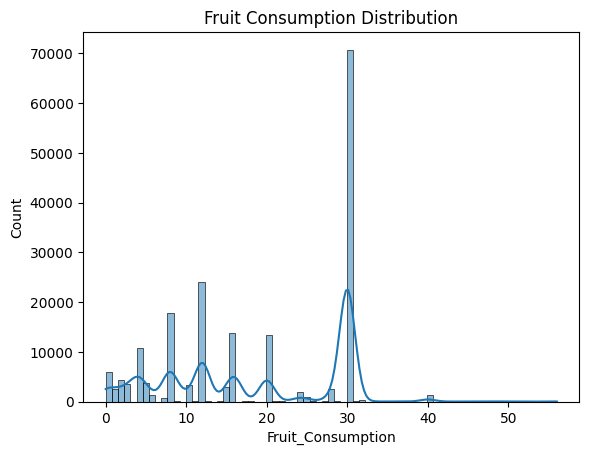

In [72]:
# Plot a graph for fruit consumption
sns.histplot(x = 'Fruit_Consumption', data = df, kde = True).set_title('Fruit Consumption Distribution')

#### Analysis of Fruit Consumption

The dataset provides detailed information on individuals’ fruit consumption patterns, measured as the number of fruit servings consumed within a given period. Understanding fruit consumption is crucial in assessing overall dietary habits and their potential association with health outcomes.
1. Frequency Distribution:
   * The most frequently reported fruit consumption level is 30 servings, observed among 70,762 individuals, representing 37.9% of the total respondents.
   * This indicates that a large proportion of people consume a moderate to high amount of fruit.
   * The next most common consumption levels are:
     * 12 servings (12.9%)
     * 8 servings (9.5%)
     * 16 servings (7.4%)
     * 20 servings (7.1%)
    * These values suggest a gradual decline in frequency as consumption levels deviate from the 30-serving range.

2. Low Fruit Consumption:
    * Around 3.17% of respondents reported zero fruit consumption, showing a small but significant group not consuming fruits at all.
    * Minimal consumption levels (1–5 servings) together account for roughly 8–9% of respondents, indicating a small subset of individuals with low fruit intake.

3. High Fruit Consumption:
    * Very high consumption levels (≥40 servings) are rare, with individual percentages falling below 1% each.
    * The highest reported consumption levels include:
      * 40 servings (0.71%)
      * 48 servings (0.06%)
      * 56 servings (0.04%)
    * This suggests that excessive fruit consumption is uncommon in the population.

4. Distribution Pattern:
    * The distribution is right-skewed, indicating that most individuals consume fruits within a moderate range (8–30 servings), while fewer people report extremely low or high consumption.
  
* The majority (over 75%) of the respondents consume between 8 and 30 servings, reflecting generally positive dietary habits.
* A small group (around 3%) does not consume fruits at all, potentially indicating an at-risk segment for nutrient deficiency.
* Promoting awareness about fruit intake among low-consuming individuals could improve overall population health outcomes.   

### Green_Vegetables_Consumption

In [75]:
# Get the unique values for green vegetables consumption
print("Green vegetables consumption in the dataset:", df['Green_Vegetables_Consumption'].value_counts())

# Get the unique values for green vegeteables consumption
print("\nPercentage of green vegetables consumption:", df['Green_Vegetables_Consumption'].value_counts(normalize = True) * 100)

Green vegetables consumption in the dataset: Green_Vegetables_Consumption
8.0     26677
12.0    26533
4.0     26464
30.0    25820
0.0     14788
16.0    14353
20.0    12550
2.0      8101
1.0      6131
3.0      4499
5.0      4211
15.0     4180
10.0     3966
24.0     1676
28.0     1599
6.0      1598
25.0     1217
7.0       945
40.0      468
14.0      253
18.0       98
9.0        95
21.0       80
32.0       67
22.0       60
17.0       56
27.0       37
26.0       35
13.0       30
23.0       28
29.0       25
11.0       21
36.0       15
31.0       14
19.0        6
35.0        6
33.0        5
44.0        3
37.0        1
Name: count, dtype: int64

Percentage of green vegetables consumption: Green_Vegetables_Consumption
8.0     14.287857
12.0    14.210732
4.0     14.173777
30.0    13.828859
0.0      7.920262
16.0     7.687281
20.0     6.721618
2.0      4.338791
1.0      3.283684
3.0      2.409606
5.0      2.255357
15.0     2.238754
10.0     2.124138
24.0     0.897644
28.0     0.856404
6.0      0

C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Green Vegetables Consumption Distribution')

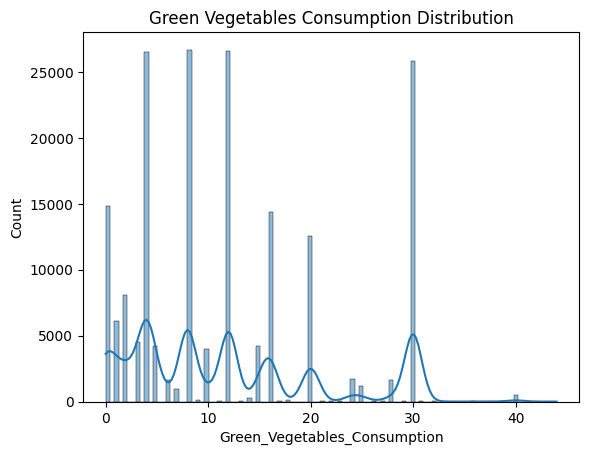

In [76]:
# Plot a graph for green vegetables consumption
sns.histplot(x = 'Green_Vegetables_Consumption', data = df, kde = True).set_title('Green Vegetables Consumption Distribution')

#### Analysis of Green Vegetables Consumption

The dataset provides insights into the frequency of green vegetable consumption among individuals. Analyzing this data helps in understanding general dietary habits and how often people include green vegetables—an essential source of vitamins, minerals, and fiber—in their diet.

1. Frequency Distribution: The most commonly reported consumption levels are:
    * 8 servings (14.29%)
    * 12 servings (14.21%)
    * 4 servings (14.17%)
    * 30 servings (13.83%)
 * These four categories together account for over 56% of all individuals, showing that the majority consume a moderate to high amount of green vegetables.
 * The next group of notable consumption levels includes:
    * 0 servings (7.92%)
    * 16 servings (7.69%)
    * 20 servings (6.72%)
* This indicates that a smaller portion of the population either does not consume vegetables at all or eats them less frequently.

2. Low Consumption Levels:
   * About 7.92% of individuals reported zero consumption of green vegetables.
   * Around 10% of respondents consume 2–5 servings, indicating a small segment with low intake, which may represent less healthy eating habits.

3. Moderate to High Consumption:
    * Most respondents (around 60–65%) fall between 4 and 20 servings, showing a generally positive trend toward vegetable inclusion in the diet.
    * A significant number (over 13%) consume 30 servings, possibly representing individuals who include vegetables in nearly every meal.

4. Very High Consumption:
    * Extremely high consumption levels (≥40 servings) are rare, with the highest being:
       * 40 servings (0.25%)
       * 44 servings (0.002%)
    * This suggests that very frequent or excessive consumption of green vegetables is uncommon.

5. Distribution Pattern:
    * The overall pattern appears right-skewed, meaning that most individuals consume a moderate amount of vegetables, while very few have extreme low or high intake levels.
  
* The majority (over 80%) of individuals consume green vegetables moderately (4–30 servings), reflecting a generally healthy dietary trend.
* Around 8% of respondents do not consume green vegetables at all, highlighting an area for dietary improvement.
* Encouraging balanced vegetable intake could further enhance nutritional health across the population.

### FriedPotato_Consumption

In [79]:
# Get the unique values for fried potato consumption
print("Fried potato consumption in the dataset:", df['FriedPotato_Consumption'].value_counts())

# Get the unique values for fried potato consumption
print("\nPercentage of fried potato vegetables consumption:", df['FriedPotato_Consumption'].value_counts(normalize = True) * 100)

Fried potato consumption in the dataset: FriedPotato_Consumption
4.0     44050
0.0     26078
8.0     26001
2.0     22594
1.0     17915
12.0    15260
3.0      9864
5.0      6768
16.0     5720
10.0     5265
15.0     3284
6.0      2147
7.0      1349
14.0      202
9.0       109
13.0       39
17.0       36
11.0       30
Name: count, dtype: int64

Percentage of fried potato vegetables consumption: FriedPotato_Consumption
4.0     23.592611
0.0     13.967040
8.0     13.925800
2.0     12.101055
1.0      9.595043
12.0     8.173059
3.0      5.283031
5.0      3.624853
16.0     3.063558
10.0     2.819866
15.0     1.758868
6.0      1.149905
7.0      0.722507
14.0     0.108189
9.0      0.058379
13.0     0.020888
17.0     0.019281
11.0     0.016068
Name: proportion, dtype: float64


C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Fried Potato Consumption Distribution')

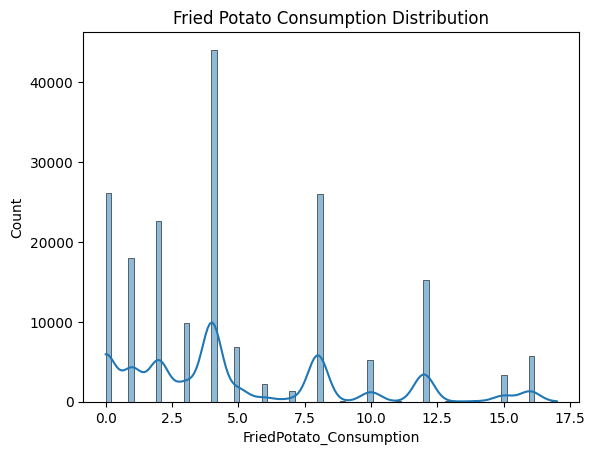

In [80]:
# Plot a graph for fried potato consumption
sns.histplot(x = 'FriedPotato_Consumption', data = df, kde = True).set_title('Fried Potato Consumption Distribution')

#### Analysis of Fried Potato Consumption

This section analyzes the frequency of fried potato consumption among individuals in the dataset. Fried potatoes include foods like French fries, chips, and other fried potato products, which are typically high in calories, fats, and sodium. Understanding the frequency of consumption helps assess general eating habits and potential health implications.

1. Frequency Distribution: 
   * The most common consumption levels are:
      * 4 servings (23.59%)
      * 0 servings (13.97%)
      * 8 servings (13.93%)
      * 2 servings (12.10%)
      * 1 serving (9.60%)
    * These top five categories make up nearly 73% of all individuals, suggesting that most people either consume fried potatoes occasionally or not at all.

2. Moderate Consumption:
   * A considerable portion of individuals (between 8 and 12 servings) accounts for around 8.17% of the total.
   * This reflects a moderate level of fried food intake, which could indicate occasional indulgence rather than daily consumption.

3. Low to Moderate Consumption (0-5 servings):
   * Nearly 63% of individuals consume fried potatoes between 0 and 5 servings.
   * This pattern indicates that while fried foods are common, most individuals limit their intake to a relatively moderate frequency.

4. High Consumption (10–17 servings):
   * High consumption levels such as 10–16 servings are less common, together accounting for around 10% of individuals.
   * Very high consumption categories (≥15 servings) collectively represent less than 2% of respondents.

5. Rare Consumption Levels:
   * Extremely high frequencies such as 14, 15, 16, and 17 servings have very low representation (below 0.2% each), showing that excessive fried potato consumption is rare.
  
6. Distribution Pattern:
   * The distribution is right-skewed, indicating that while some individuals consume large amounts of fried potatoes, the majority have moderate or low consumption levels.
  
* A significant portion of the population (nearly three-fourths) either avoids or consumes fried potatoes infrequently (0–4 servings).
* High consumption (10 or more servings) is relatively rare but still present, suggesting a small subset with higher calorie intake from fried foods.
* Given the link between high fried food consumption and cardiovascular risks, these results highlight the importance of promoting healthier eating habits and encouraging reduced fried food intake.

These plots visualizes the food and drinking habits of the patients. From these plots, it is clear that majority of the patients, do not consume alcohol. Coming to the food habits, most of the patients, consume higher amount of fruits and green vegetables which is good for health. However, most of the patients consume fried potatoes which is not good for health. This means that the patients who consume fried potatoes and alcohol are more likely to have cardiovascular disease.

### Medical History

1. Heart_Disease
2. Skin_Cancer
3. Other_Cancer
4. Depression
5. Diabetes
6. Arthritis

### Heart Disease

In [85]:
# Get the unique values for heart disease
print("Different types of heart disease in the dataset:", df['Heart_Disease'].unique())

# Get the value count for heart disease
print("\nNumber of counts of heart disease in the dataset:", df['Heart_Disease'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of differnt types of heart diasease in the dataset:", df['Heart_Disease'].value_counts(normalize = True) * 100)

Different types of heart disease in the dataset: ['No' 'Yes']

Number of counts of heart disease in the dataset: Heart_Disease
No     170768
Yes     15943
Name: count, dtype: int64

Percentage of differnt types of heart diasease in the dataset: Heart_Disease
No     91.461135
Yes     8.538865
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Heart Disease')

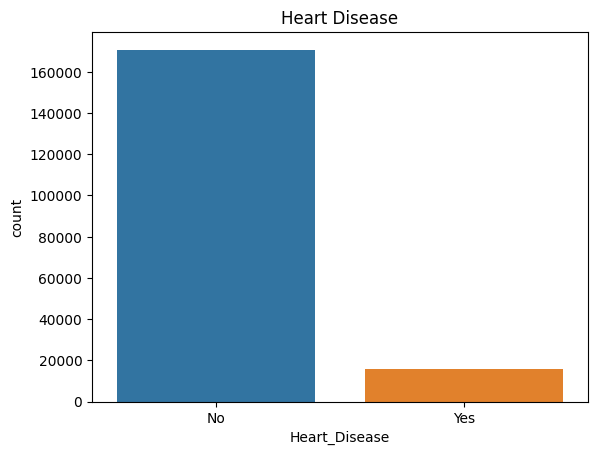

In [86]:
# Plot a graph for heart disease
sns.countplot(x = 'Heart_Disease', data = df).set_title('Heart Disease')

#### Analysis of Heart Disease in the Dataset

This section explores the prevalence of heart disease among individuals in the dataset. Understanding the proportion of people diagnosed with heart disease provides insight into overall population health and can help identify potential risk factors related to lifestyle or other medical conditions.

1. Types of Heart Disease Status: The dataset categorizes individuals into two groups:
   * Yes – Individuals diagnosed with heart disease.
   * No – Individuals not diagnosed with heart disease.

| Heart Disease | Count | Percentage (%) |
|---------------|-------|----------------|
| Yes | 15943 | 8.54 |
| No | 170768 | 91.46 |

* The data shows that heart disease affects a smaller portion of the population in this dataset.
* However, an 8.54% prevalence is still significant, as heart disease remains one of the leading causes of death worldwide.
* The results suggest that further analysis could be valuable to understand:
  * How lifestyle factors (e.g., exercise, diet, alcohol consumption, smoking) correlate with heart disease.
  * Whether demographic variables (such as age, gender, or BMI) play a role in its prevalence.

The dataset reveals that 91.46% of individuals do not suffer from heart disease, while 8.54% do. Although the proportion of diagnosed cases is relatively low, this still represents a considerable segment of the population.
Further exploration of this group in relation to exercise habits, dietary patterns, and other health indicators could provide deeper insights into the risk factors contributing to heart disease.

### Skin Cancer

In [89]:
# Get the unique values for heart disease
print("Different types of skin cancer in the dataset:", df['Skin_Cancer'].unique())

# Get the value count for heart disease
print("\nNumber of counts of skin cancer in the dataset:", df['Skin_Cancer'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of skin cancer in the dataset:", df['Skin_Cancer'].value_counts(normalize = True) * 100)

Different types of skin cancer in the dataset: ['No' 'Yes']

Number of counts of skin cancer in the dataset: Skin_Cancer
No     169388
Yes     17323
Name: count, dtype: int64

Percentage of skin cancer in the dataset: Skin_Cancer
No     90.722025
Yes     9.277975
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Skin Cancer Distribution')

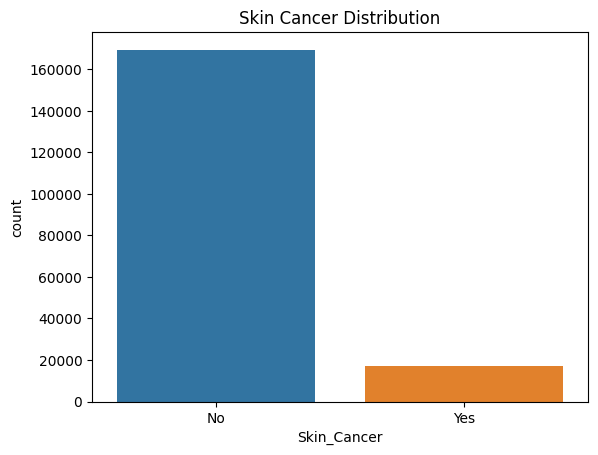

In [90]:
# Plot a graph for heart disease
sns.countplot(x = 'Skin_Cancer', data = df).set_title('Skin Cancer Distribution')

#### Analysis of Skin Cancer in the Dataset

The Skin_Cancer column contains two categories: Yes and No

| Skin Cancer | Count | Percentage |
|-------------|-------|------------|
| No | 169,388 | 90.72 |
| Yes | 17,323 | 9.28 |

A large majority of individuals (90.72%) do not have skin cancer, whereas 9.28% of the population is affected. This indicates that skin cancer is relatively less prevalent but still present in a notable portion of the dataset.

### Other Cancer

In [93]:
# Get the unique values for heart disease
print("Different types of other cancer in the dataset:", df['Other_Cancer'].unique())

# Get the value count for heart disease
print("\nNumber of counts of other cancer in the dataset:", df['Other_Cancer'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of other cancer in the dataset:", df['Other_Cancer'].value_counts(normalize = True) * 100)

Different types of other cancer in the dataset: ['No' 'Yes']

Number of counts of other cancer in the dataset: Other_Cancer
No     168608
Yes     18103
Name: count, dtype: int64

Percentage of other cancer in the dataset: Other_Cancer
No     90.304267
Yes     9.695733
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Other Cancer Distribution')

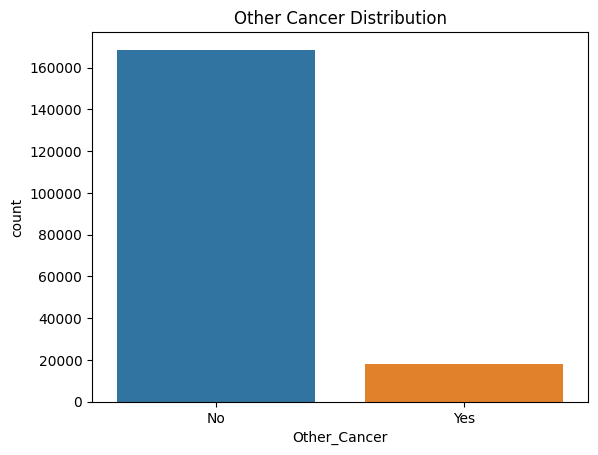

In [94]:
# Plot a graph for heart disease
sns.countplot(x = 'Other_Cancer', data = df).set_title('Other Cancer Distribution')

#### Analysis of Other Cancer in the Dataset

The Other_Cancer column also contains two categories: Yes and No.

| Other Cancer | Count | Percentage |
|--------------|-------|------------|
| No | 168,608 | 90.30 |
| Yes | 18,103 | 9.69 |

Similar to skin cancer, most individuals (90.30%) do not have other types of cancer, while 9.70% of the population is affected. This shows that other cancers are also relatively less common but still present in the dataset.

### Depression

In [97]:
# Get the unique values for heart disease
print("Different types of depression in the dataset:", df['Depression'].unique())

# Get the value count for heart disease
print("\nNumber of counts of depression in the dataset:", df['Depression'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of depression in the dataset:", df['Depression'].value_counts(normalize = True) * 100)

Different types of depression in the dataset: ['No' 'Yes']

Number of counts of depression in the dataset: Depression
No     149493
Yes     37218
Name: count, dtype: int64

Percentage of depression in the dataset: Depression
No     80.06652
Yes    19.93348
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Depression Distribution')

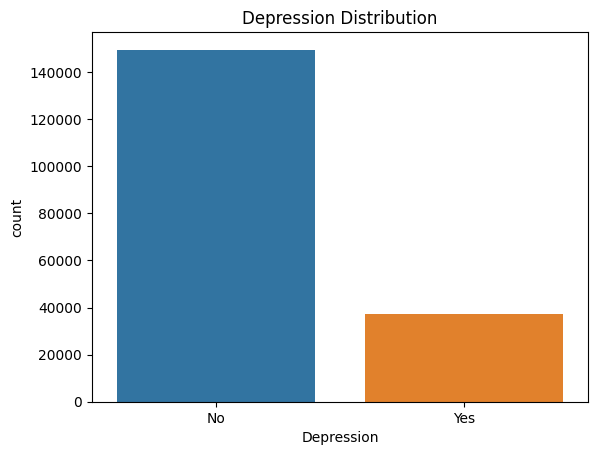

In [98]:
# Plot a graph for heart disease
sns.countplot(x = 'Depression', data = df).set_title('Depression Distribution')

#### Analysis of Depression in the Dataset

The Depression column in the dataset contains two categories: Yes and No. 

| Depression | Count | Percentage |
|------------|-------|------------|
| No | 149,493 | 80.07 |
| Yes | 37,218 | 19.93 |

The majority of individuals in the dataset (80.07%) do not report depression, while 19.93% have depression. This indicates that nearly one-fifth of the population is affected by depression, highlighting its significance as a mental health concern in the dataset.

### Diabetes

In [101]:
# Get the unique values for Diabetes
print("Different types of Diabetes in the dataset:", df['Diabetes'].unique())

Different types of Diabetes in the dataset: ['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']


The diabetes column has four values - Yes, No, No pre-diabetes or borderline diabetes and Yes, but female told only during pregnancy. So replacing the last two values with pre-diabetes and gestational diabetes, respectively.

In [103]:
# Rename specific values in the 'Diabetes' column
df['Diabetes'] =  df['Diabetes'].replace({
    'No, pre-diabetes or borderline diabetes': 'Prediabetes',
    'Yes, but female told only during pregnancy': 'Gestational Diabetes'})

# Verify the changes
print('Different types of diabetes in the dataset:', df['Diabetes'].unique())

Different types of diabetes in the dataset: ['No' 'Yes' 'Prediabetes' 'Gestational Diabetes']


In [104]:
# Get the value count for heart disease
print("\nNumber of counts of Diabetes in the dataset:", df['Diabetes'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of Diabetes in the dataset:", df['Diabetes'].value_counts(normalize = True) * 100)


Number of counts of Diabetes in the dataset: Diabetes
No                      155348
Yes                      25456
Prediabetes               4339
Gestational Diabetes      1568
Name: count, dtype: int64

Percentage of Diabetes in the dataset: Diabetes
No                      83.202382
Yes                     13.633905
Prediabetes              2.323912
Gestational Diabetes     0.839801
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Diabetes Distribution')

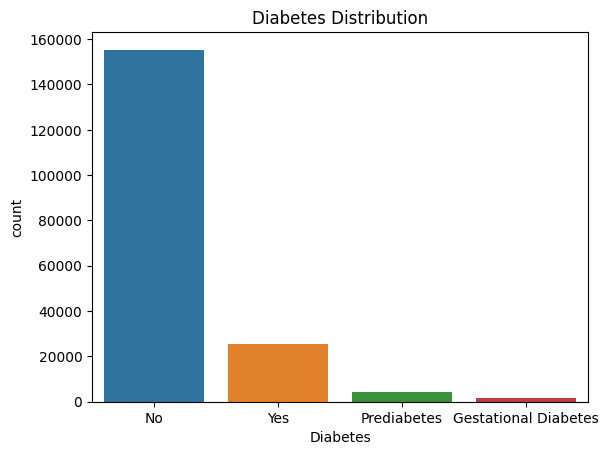

In [105]:
# Plot a graph for heart disease
sns.countplot(x = 'Diabetes', data = df).set_title('Diabetes Distribution')

#### Analysis of Diabetes in the Dataset

The Diabetes column in the dataset originally contained four values:
* No
* Yes
* No, pre-diabetes or borderline diabetes
* Yes, but female told only during pregnancy

To make the data clearer and more meaningful, the last two categories were renamed as follows:
* No, pre-diabetes or borderline diabetes" → "Prediabetes
* Yes, but female told only during pregnancy" → "Gestational Diabetes

After renaming, the Diabetes column now contains the following categories:

| Diabetes Type | Count | Percentage (%) |
|---------------|-------|----------------|
| No | 155,348 | 83.20 |
| Yes | 25,456 | 13.63 |
| Prediabtes | 4,339 | 2.32 |
| Gestational Diabetes | 1,568 | 0.83 | 

The majority of individuals in the dataset do not have diabetes (83.20%). About 13.63% have diabetes, while smaller proportions have prediabetes (2.32%) or gestational diabetes (0.84%). This recoding provides clearer categories for further analysis and visualization.

### Arthritis

In [108]:
# Get the unique values for Arthritis
print("Different types of arthritis in the dataset:", df['Arthritis'].unique())

# Get the value count for heart disease
print("\nNumber of counts of arthritis in the dataset:", df['Arthritis'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of arthritis in the dataset:", df['Arthritis'].value_counts(normalize = True) * 100)

Different types of arthritis in the dataset: ['Yes' 'No']

Number of counts of arthritis in the dataset: Arthritis
No     126067
Yes     60644
Name: count, dtype: int64

Percentage of arthritis in the dataset: Arthritis
No     67.519857
Yes    32.480143
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Arthritis Distribution')

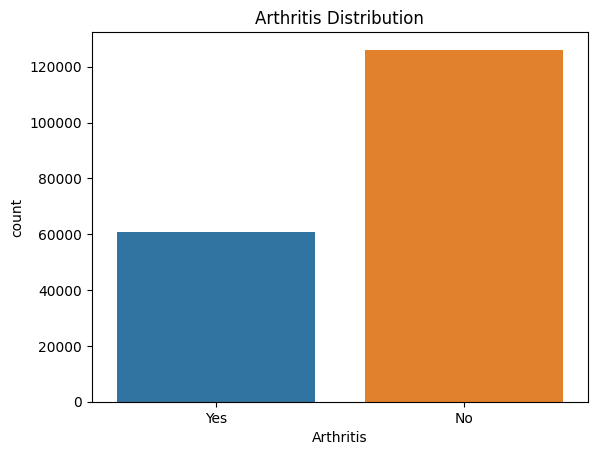

In [109]:
# Plot a graph for heart disease
sns.countplot(x = 'Arthritis', data = df).set_title('Arthritis Distribution')

#### Analysis of Arthritis in the Dataset

The Arthritis column in the dataset has two categories:
* Yes -
* No -

| Arthritis | Count | Percentage |
|-----------|-------|------------|
| No | 126,067 | 67.52 | 
| Yes | 60644 | 32.48 |

The majority of individuals in the dataset (67.52%) do not have arthritis, while approximately one-third (32.48%) have arthritis. This indicates a significant prevalence of arthritis in the population, which may be relevant for health-related analyses and interventions.

### Smoking History

In [112]:
# Get the unique values for Arthritis
print("Different types of Smoking History in the dataset:", df['Smoking_History'].unique())

# Get the value count for heart disease
print("\nNumber of counts of Smoking History in the dataset:", df['Smoking_History'].value_counts())

# Geth the percentage of heart diseae in the dataset
print("\nPercentage of smoking history in the dataset:", df['Smoking_History'].value_counts(normalize = True) * 100)

Different types of Smoking History in the dataset: ['Yes' 'No']

Number of counts of Smoking History in the dataset: Smoking_History
No     111328
Yes     75383
Name: count, dtype: int64

Percentage of smoking history in the dataset: Smoking_History
No     59.625839
Yes    40.374161
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Smoking History Distribution')

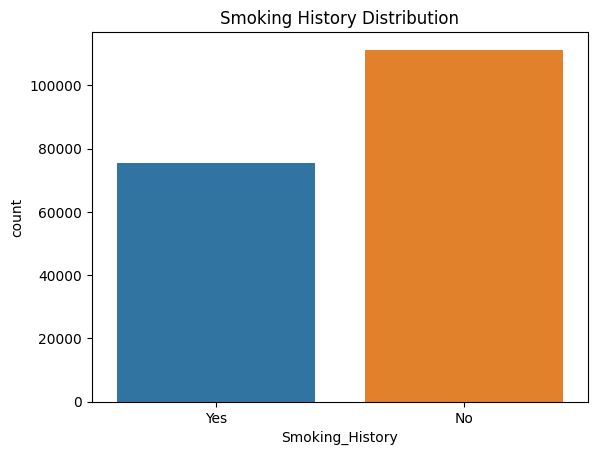

In [113]:
# Plot a graph for heart disease
sns.countplot(x = 'Smoking_History', data = df).set_title('Smoking History Distribution')

#### Analysis of Smoking History in the Dataset

The Smoking_History column in the dataset contains two categories: Yes and No.

| Smoking History | Count | Percentage |
|-----------------|-------|------------|
| No | 111,328 | 59.63 |
| Yes | 75,383 | 40.37 |

A majority of individuals (59.63%) do not have a history of smoking, whereas 40.37% have smoked at some point. This indicates a substantial proportion of the population with a history of smoking, which could be an important factor when analyzing health outcomes such as heart disease, diabetes, or respiratory conditions.

### Target Variable (Dependent) and Independent Variables Visualization

### Patient's Demographics and Heart Disease

Visualizing the patient's demographics along with the heart disease, help us to know more about the relation of cardiovascular disease with patient. 

### Sex and Heart Disease 

In [118]:
# Create a crosstab to get counts
sex_heart_counts = pd.crosstab(df['Sex'], df['Heart_Disease'])

# Convert counts to percentages within each sex
sex_heart_percent = sex_heart_counts.div(sex_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
sex_heart_percent = sex_heart_percent.reset_index().melt(id_vars='Sex', var_name='Heart_Disease', value_name='Percentage')
print(sex_heart_percent)

      Sex Heart_Disease  Percentage
0  Female            No   93.399042
1    Male            No   89.388750
2  Female           Yes    6.600958
3    Male           Yes   10.611250


Text(0.5, 1.0, 'Sex vs Heart Disease')

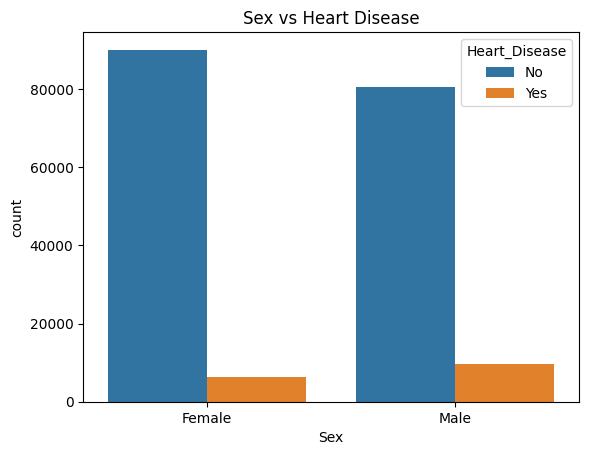

In [119]:
# Plot a graph for sex and heart disease
sns.countplot(x = 'Sex', hue = 'Heart_Disease', data = df).set_title('Sex vs Heart Disease')

#### Analysis of Heart Disease by Gender

The analysis of the relationship between gender and heart disease reveals a noticeable difference between males and females. Based on the data:

| Sex | Heart Disease Status | Percentage | Interpretation |
|-----|----------------------|------------|----------------|
| Female | No | 93.39 | Majority of females do not have heart disease. |
| Male | No | 89.38 | Most males do not have heart disease. |
| Female | Yes | 6.60 | A small percentage of females are affected by heart disease. |
| Male | Yes | 10.61 | Males are more prone to heart disease compared to females. |

These percentages clearly show that males are more prone to heart disease compared to females. The higher prevalence among males could be attributed to various biological, lifestyle, and behavioral factors such as stress levels, smoking habits, diet, and genetic predisposition.

From the above table, it is evident that males have a higher prevalence of heart disease (10.61%) compared to females (6.60%), indicating that gender may influence heart disease risk.

### Age Category and Heart Disease

In [122]:
# Create a crosstab to get counts
age_heart_counts = pd.crosstab(df['Age_Category'], df['Heart_Disease'])

# Convert counts to percentages within each sex
age_heart_percent = age_heart_counts.div(age_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
age_heart_percent = age_heart_percent.reset_index().melt(id_vars='Age_Category', var_name='Heart_Disease', value_name='Percentage')
print(age_heart_percent)

   Age_Category Heart_Disease  Percentage
0         18-24            No   99.602756
1         25-29            No   99.403292
2         30-34            No   98.960499
3         35-39            No   98.634926
4         40-44            No   97.976391
5         45-49            No   96.695930
6         50-54            No   95.213154
7         55-59            No   92.555905
8         60-64            No   90.064284
9         65-69            No   87.785915
10        70-74            No   84.066808
11        75-79            No   80.967152
12          80+            No   77.247110
13        18-24           Yes    0.397244
14        25-29           Yes    0.596708
15        30-34           Yes    1.039501
16        35-39           Yes    1.365074
17        40-44           Yes    2.023609
18        45-49           Yes    3.304070
19        50-54           Yes    4.786846
20        55-59           Yes    7.444095
21        60-64           Yes    9.935716
22        65-69           Yes   12

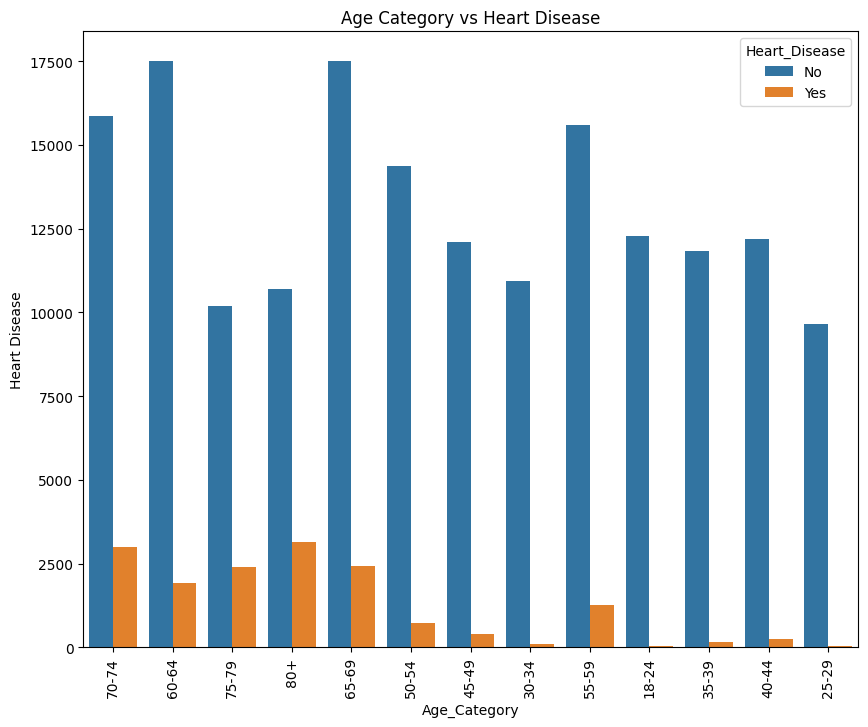

In [123]:
# Plot a graph for sex and heart disease
plt.figure(figsize = (10, 8))
sns.countplot(x = 'Age_Category', hue = 'Heart_Disease', data = df)
plt.title('Age Category vs Heart Disease')
plt.xlabel = ('Age Category')
plt.ylabel('Heart Disease')
plt.xticks(rotation = 90)
plt.show()

#### Heart Disease Distribution by Age Category

| Age Category | Heart Disease: No (%) | Heart Disease: Yes (%) | Interpretation |
|--------------|-----------------------|------------------------|----------------|
| 18-24 | 99.60 | 0.39 | Very few young adults show signs of heart disease. |
| 25-29 | 99.40 | 0.59 | Heart disease remains very rare in this age group. |
| 30–34 | 98.96 | 1.03 | Slight increase in heart disease prevalence begins. |
| 35–39 | 98.63 | 1.36 | Gradual rise in cases as age increases. |
| 40-44 | 97.97 | 2.02 | Noticeable increase in heart disease occurrence. |
| 45–49 | 96.69 | 3.30 | Risk continues to rise with age. |
| 50–54 | 95.21 | 4.78 | One in twenty people in this age group may have heart disease. |
| 55-59 | 92.55 | 7.44 | Heart disease becomes more common. |
| 60-64 | 90.06 | 9.93 | Nearly 10% of this group is affected. |
| 65–69 | 87.78 | 12.21 | Heart disease affects about 12% of this group. |
| 70–74 | 84.06 | 15.93 | Heart disease continues to increase significantly. |
| 75–79 | 80.96 | 19.03 | Almost one in five people in this group has heart disease. |
| 80+ | 77.24 | 22.75 | More than one in five people aged 80+ suffer from heart disease. |


* The analysis reveals a clear and consistent upward trend in the prevalence of heart disease with increasing age.
* Heart disease prevalence increases steadily with age.
* Individuals aged 55 years and older show a sharp increase in heart disease cases compared to younger age groups.
* The highest percentage of heart disease (22.75%) is found among those aged 80 years and above, indicating that older adults are more prone to cardiovascular diseases.
* This trend confirms that age is a major risk factor for heart disease, with the likelihood of developing cardiovascular conditions rising significantly with advancing age.

As age increases, so does the risk of heart disease. This pattern suggests the need for preventive healthcare measures and lifestyle modifications for middle-aged and elderly individuals to reduce the risk of cardiovascular complications.

### BMI and Heart Disease

In [126]:
# Create a crosstab to get counts
bmi_heart_counts = pd.crosstab(df['BMI'], df['Heart_Disease'])

# Convert counts to percentages within each sex
bmi_heart_percent = bmi_heart_counts.div(bmi_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
bmi_heart_percent = bmi_heart_percent.reset_index().melt(id_vars='BMI', var_name='Heart_Disease', value_name='Percentage')
print(bmi_heart_percent)

        BMI Heart_Disease  Percentage
0     12.87            No  100.000000
1     12.88            No  100.000000
2     12.89            No  100.000000
3     12.91            No  100.000000
4     12.92            No  100.000000
...     ...           ...         ...
4669  43.22           Yes   20.000000
4670  43.24           Yes   12.000000
4671  43.26           Yes   23.529412
4672  43.27           Yes   13.186813
4673  43.28           Yes   14.285714

[4674 rows x 3 columns]


C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ganga\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

Text(0.5, 1.0, 'BMI vs Heart Disease')

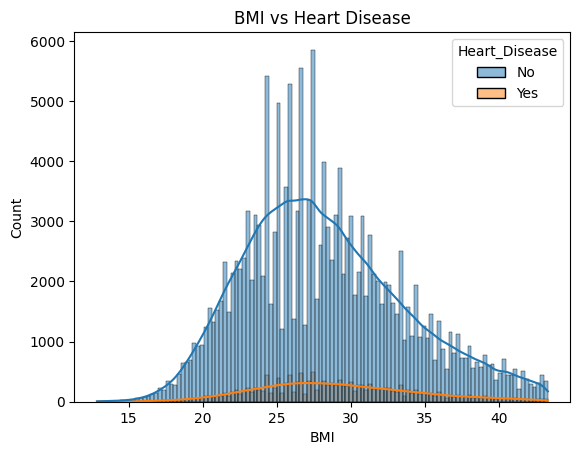

In [127]:
# Plot a graph for sex and heart disease
sns.histplot(x = 'BMI', hue = 'Heart_Disease', data = df, kde = True).set_title('BMI vs Heart Disease')

#### Relationship Between BMI and Heart Disease

* The analysis of Body Mass Index (BMI) reveals that individuals with a BMI between 25 and 30, classified as overweight, show a noticeably higher prevalence of heart disease compared to other BMI categories.
* As BMI increases beyond the normal range (18.5–24.9), the percentage of individuals diagnosed with heart disease also tends to rise. This trend continues into the obese range (BMI ≥ 30), indicating that excess body weight contributes significantly to cardiovascular risk.
* In contrast, individuals with lower BMI values (below 25) have minimal or no reported cases of heart disease, suggesting a protective effect of maintaining a healthy weight.
* This finding aligns with established medical research that links overweight and obesity to increased blood pressure, cholesterol imbalance, and higher strain on the heart, all of which elevate the risk of cardiovascular diseases.

### General Health and Heart Disease

In [130]:
# Create a crosstab to get counts
generalhealth_heart_counts = pd.crosstab(df['General_Health'], df['Heart_Disease'])

# Convert counts to percentages within each sex
generalhealth_heart_percent = generalhealth_heart_counts.div(generalhealth_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
generahealth_heart_percent = generalhealth_heart_percent.reset_index().melt(id_vars='General_Health', var_name='Heart_Disease', value_name='Percentage')
print(generahealth_heart_percent)

  General_Health Heart_Disease  Percentage
0      Excellent            No   97.987309
1           Fair            No   80.070625
2           Good            No   90.718232
3           Poor            No   67.252284
4      Very Good            No   95.567271
5      Excellent           Yes    2.012691
6           Fair           Yes   19.929375
7           Good           Yes    9.281768
8           Poor           Yes   32.747716
9      Very Good           Yes    4.432729


Text(0.5, 1.0, 'General Health vs Heart Disease')

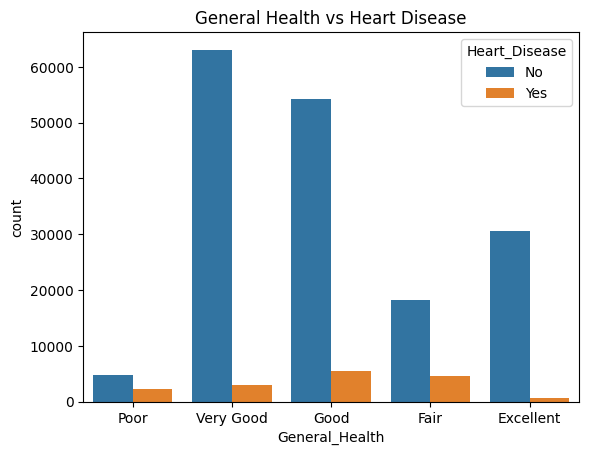

In [131]:
# Plot a graph for general health and heart disease
sns.countplot(x = 'General_Health', hue = 'Heart_Disease', data = df).set_title('General Health vs Heart Disease')

#### Relationship Between General Health and Heart Disease

* At first glance, one might expect that individuals reporting “Excellent” or “Very Good” general health would have a significantly lower incidence of heart disease. However, the data presents an interesting insight.

* While the majority of people with Excellent (97.99%) and Very Good (95.57%) health do not have heart disease, a small proportion (2–4%) within these groups are affected. On the other hand, individuals reporting Poor (32.75%) or Fair (19.93%) health have a much higher percentage of heart disease cases.

* This indicates that self-perceived general health does have a strong relationship with heart disease — people who perceive their health as poor are more likely to have heart disease.

* If your graph seemed to show otherwise (e.g., the “Good” or “Very Good” categories appearing taller), it might be due to the larger population size in those categories. More people generally rate their health as “Good” or “Very Good,” so even if the percentage of heart disease is lower, the count of cases appears higher.

* Poor/Fair health → Higher risk (19–33%)
* Good/Very Good/Excellent health → Lower risk (2–9%)
* The apparent contradiction arises from unequal group sizes, not a true reversal of the health–disease relationship.

### Checkup and Heart Disease

In [134]:
# Create a crosstab to get counts
checkup_heart_counts = pd.crosstab(df['Checkup'], df['Heart_Disease'])

# Convert counts to percentages within each checkup
checkup_heart_percent = checkup_heart_counts.div(checkup_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
checkup_heart_percent = checkup_heart_percent.reset_index().melt(id_vars='Checkup', var_name='Heart_Disease', value_name='Percentage')
print(checkup_heart_percent)

                   Checkup Heart_Disease  Percentage
0      5 or more years ago            No   97.589905
1                    Never            No   96.118721
2  Within the past 2 years            No   96.099433
3  Within the past 5 years            No   97.304480
4     Within the past year            No   89.956335
5      5 or more years ago           Yes    2.410095
6                    Never           Yes    3.881279
7  Within the past 2 years           Yes    3.900567
8  Within the past 5 years           Yes    2.695520
9     Within the past year           Yes   10.043665


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Within the past 2 years'),
  Text(1, 0, 'Within the past year'),
  Text(2, 0, '5 or more years ago'),
  Text(3, 0, 'Within the past 5 years'),
  Text(4, 0, 'Never')])

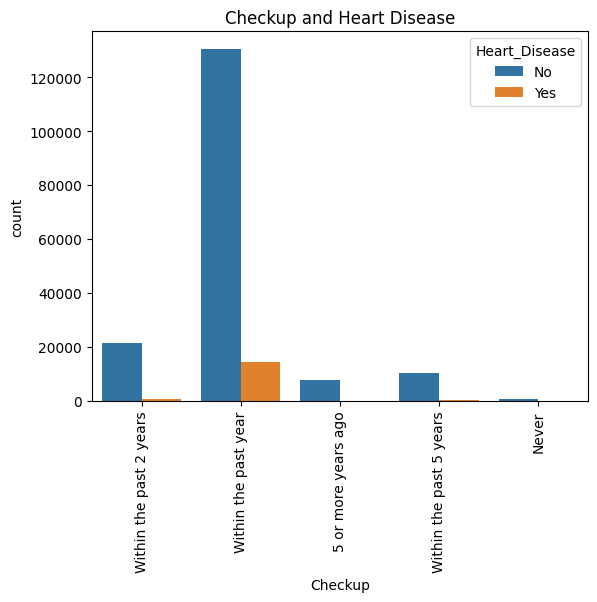

In [135]:
# Plot a graph for Checkup and heart disease
sns.countplot(x = 'Checkup', data = df, hue  = 'Heart_Disease').set_title('Checkup and Heart Disease')
plt.xticks(rotation=90)

#### Relationship Between Frequency of Checkups and Heart Disease

* From the data, patients who had a medical checkup within the past year show a higher percentage of heart disease (10.04%) compared to those who had checkups less frequently or never.

* This does not necessarily mean that frequent checkups increase the risk of heart disease. Instead, it likely indicates that individuals who already experience symptoms or have health concerns are more proactive in seeking medical care, leading to earlier detection of cardiovascular diseases.

* Conversely, individuals who rarely or never get checkups may have undiagnosed conditions, explaining their lower recorded heart disease rates in the data.
* Checkup within past year → 10.0% with heart disease
* Less frequent/never → ~2–4% with heart disease
* Frequent health checkups are linked to early detection, not higher risk.

### Exercise and Heart Disease

In [138]:
# Create a crosstab to get counts
exercise_heart_counts = pd.crosstab(df['Exercise'], df['Heart_Disease'])

# Convert counts to percentages within each checkup
exercise_heart_percent = exercise_heart_counts.div(exercise_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
exercise_heart_percent = exercise_heart_percent.reset_index().melt(id_vars='Exercise', var_name='Heart_Disease', value_name='Percentage')
print(exercise_heart_percent)

  Exercise Heart_Disease  Percentage
0       No            No   86.669136
1      Yes            No   93.023223
2       No           Yes   13.330864
3      Yes           Yes    6.976777


Text(0.5, 1.0, 'Exercise and Heart Disease')

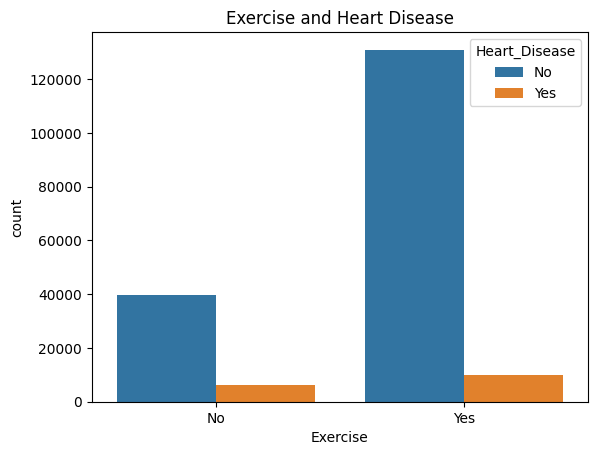

In [139]:
# Plot a graph for Exercise and heart disease
sns.countplot(x = 'Exercise', data = df, hue  = 'Heart_Disease').set_title('Exercise and Heart Disease')

#### Relationship Between Exercise and Heart Disease

* The data shows that individuals who engage in regular exercise have a lower prevalence of heart disease (6.98%), compared to those who do not exercise (13.33%).
* This suggests that regular physical activity may help reduce the risk of heart disease by improving cardiovascular health and maintaining a healthy body weight.
Therefore, the belief that exercise protects against heart disease is supported by the data — individuals who do not exercise are nearly twice as likely to have heart disease compared to those who exercise regularly.

### Food Consumption and Heart Disease

Text(0.5, 1.0, 'FriedPotato Consumption and Heart Disease')

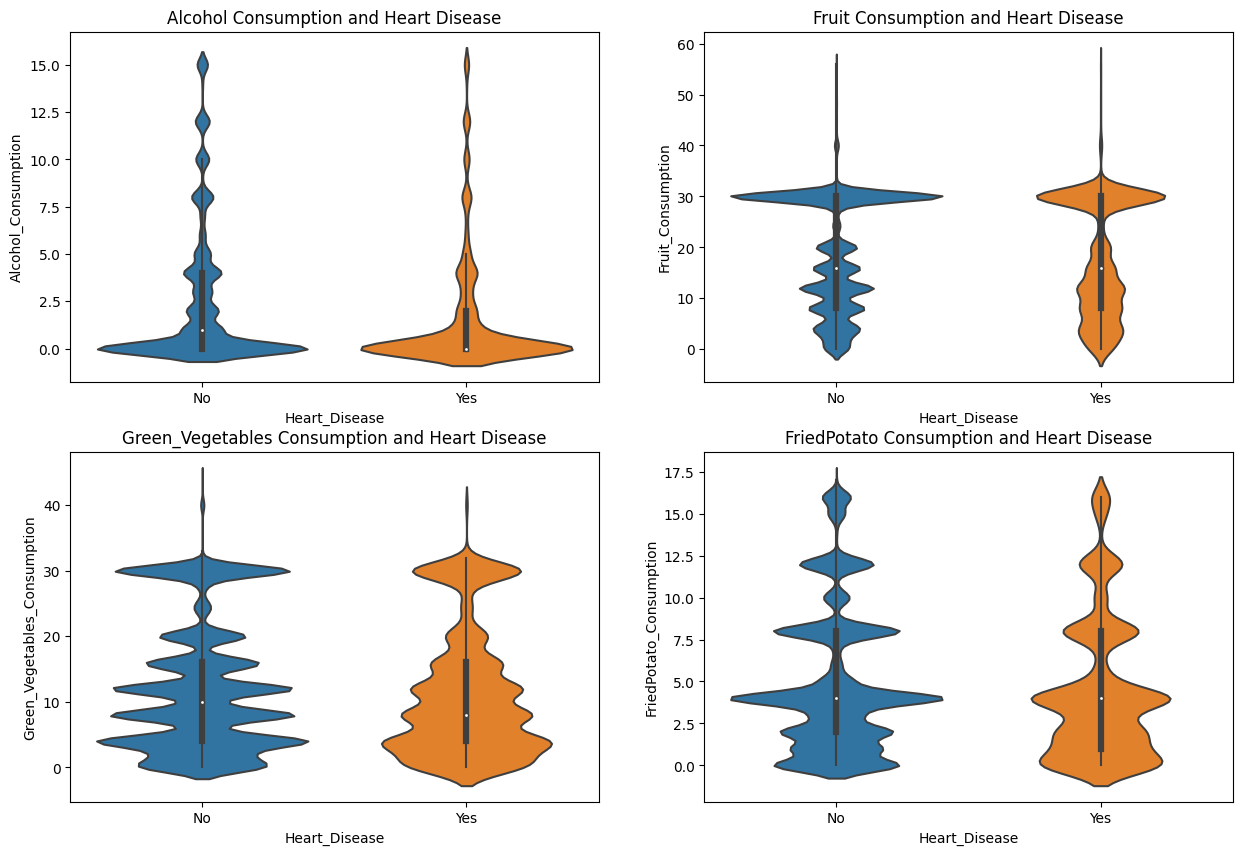

In [142]:
# Plot a graph for alcohol, fruit, green vegetables and fried potato consumption and heart disease
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
sns.violinplot(x = 'Heart_Disease', y = 'Alcohol_Consumption', data = df, ax = ax[0,0]).set_title('Alcohol Consumption and Heart Disease')
sns.violinplot(x = 'Heart_Disease', y = 'Fruit_Consumption', data = df, ax = ax[0,1]).set_title('Fruit Consumption and Heart Disease')
sns.violinplot(x = 'Heart_Disease', y = 'Green_Vegetables_Consumption', data = df, ax = ax[1,0]).set_title('Green_Vegetables Consumption and Heart Disease')
sns.violinplot(x = 'Heart_Disease', y = 'FriedPotato_Consumption', data = df, ax = ax[1,1]).set_title('FriedPotato Consumption and Heart Disease')

These graphs visualizes the patient's food and drinking habit along with their heart disease. Looking at the alcohol consumption graph, we can see that patients with increased alcohol consumption tend to have lower chances of heart disease. However, the patients with higher consumption on fruits and green vegetables, tend to have lower risk of heart diseases. In addition to that, patients with higher consumption of fried potatoes tend to have higher risk of heart disease.

### Medical History

### Smoking History and Heart Disease

In [146]:
# Create a crosstab to get counts
smoking_heart_counts = pd.crosstab(df['Smoking_History'], df['Heart_Disease'])
print(smoking_heart_counts)
# Convert counts to percentages within each checkup
smoking_heart_percent = smoking_heart_counts.div(smoking_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
smoking_heart_percent = smoking_heart_percent.reset_index().melt(id_vars='Smoking_History', var_name='Heart_Disease', value_name='Percentage')
print(smoking_heart_percent)

Heart_Disease        No   Yes
Smoking_History              
No               104808  6520
Yes               65960  9423
  Smoking_History Heart_Disease  Percentage
0              No            No   94.143432
1             Yes            No   87.499834
2              No           Yes    5.856568
3             Yes           Yes   12.500166


Text(0.5, 1.0, 'Smoking History And Heart Disease')

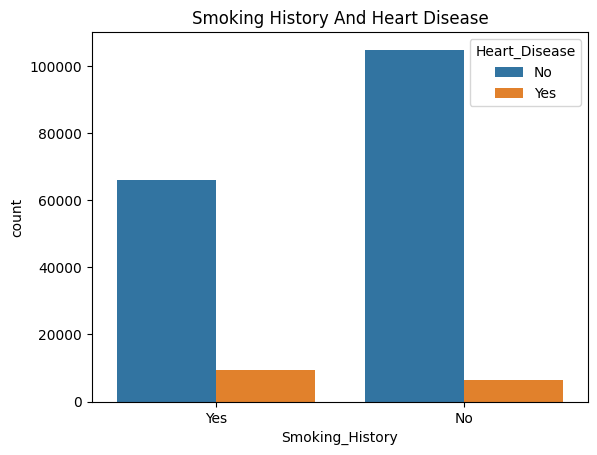

In [147]:
# Plot a graph between smoking history and heart disease
sns.countplot(x = 'Smoking_History', hue = 'Heart_Disease', data = df).set_title('Smoking History And Heart Disease')

#### Relationship Between Smoking History and Heart Disease

* The data reveals that individuals with a history of smoking have a higher prevalence of heart disease (12.50%) compared to those who have never smoked (5.86%).
This indicates that smoking is a significant risk factor for cardiovascular diseases, as smokers or former smokers are more likely to develop heart-related conditions than non-smokers.

### Skin Cancer and Heart Disease

In [150]:
# Create a crosstab to get counts
skincancer_heart_counts = pd.crosstab(df['Skin_Cancer'], df['Heart_Disease'])
print(skincancer_heart_counts)
# Convert counts to percentages within each checkup
skincancer_heart_percent = skincancer_heart_counts.div(skincancer_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
skincancer_heart_percent = skincancer_heart_percent.reset_index().melt(id_vars='Skin_Cancer', var_name='Heart_Disease', value_name='Percentage')
print(skincancer_heart_percent)

Heart_Disease      No    Yes
Skin_Cancer                 
No             156400  12988
Yes             14368   2955
  Skin_Cancer Heart_Disease  Percentage
0          No            No   92.332397
1         Yes            No   82.941754
2          No           Yes    7.667603
3         Yes           Yes   17.058246


Text(0.5, 1.0, 'Skin Cancer And Heart Disease')

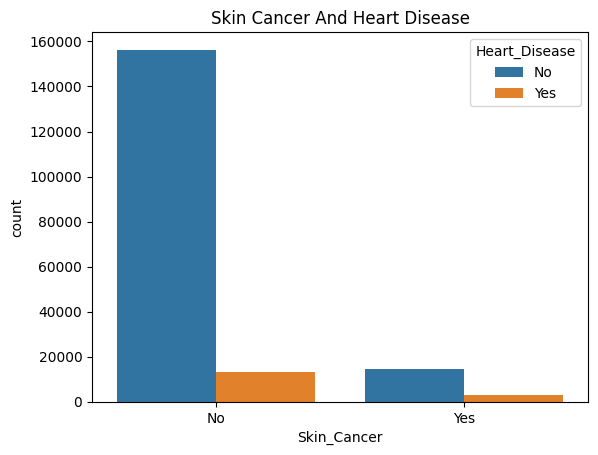

In [151]:
# Plot a graph between skin cancer and heart disease
sns.countplot(x = 'Skin_Cancer', hue = 'Heart_Disease', data = df).set_title('Skin Cancer And Heart Disease')

#### Analysis of Skin Cancer and Heart Disease Relationship

The relationship between skin cancer and heart disease reveals an interesting pattern. Based on the dataset:

| Skin Cancer | Heart Disease: No (%) | Heart Disease: Yes (%) |
|-------------|-----------------------|------------------------|
| No | 92.33 | 7.67 |
| Yes | 82.94 | 17.06 |

* Patients without skin cancer have a lower rate of heart disease (7.67%) compared to those with skin cancer (17.06%).
* Although more total heart disease cases are found among people without skin cancer (due to a larger population in that category), the proportion of individuals with both conditions is significantly higher among skin cancer patients.
* This indicates that individuals diagnosed with skin cancer are more likely to have heart disease compared to those without skin cancer. This association may be influenced by shared risk factors such as age, lifestyle habits, or underlying health conditions.

### Other Cancer and Heart Disease

In [154]:
# Create a crosstab to get counts
othercancer_heart_counts = pd.crosstab(df['Other_Cancer'], df['Heart_Disease'])
print(othercancer_heart_counts)
# Convert counts to percentages within each checkup
othercancer_heart_percent = othercancer_heart_counts.div(othercancer_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
othercancer_heart_percent = othercancer_heart_percent.reset_index().melt(id_vars='Other_Cancer', var_name='Heart_Disease', value_name='Percentage')
print(othercancer_heart_percent)

Heart_Disease      No    Yes
Other_Cancer                
No             155701  12907
Yes             15067   3036
  Other_Cancer Heart_Disease  Percentage
0           No            No   92.344966
1          Yes            No   83.229299
2           No           Yes    7.655034
3          Yes           Yes   16.770701


Text(0.5, 1.0, 'Other Cancer And Heart Disease')

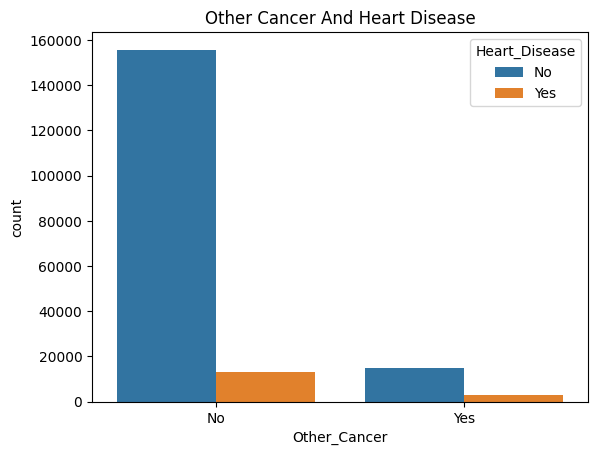

In [155]:
# Plot a graph between other cancer and heart disease
sns.countplot(x = 'Other_Cancer', hue = 'Heart_Disease', data = df).set_title('Other Cancer And Heart Disease')

#### Analysis of Other Cancer and Heart Disease Relationship

The relationship between other types of cancer and heart disease in the dataset can be summarized as follows:

| Other Cancer | Heart Disease: No (%) | Heart Disease: Yes (%) |
|--------------|-----------------------|------------------------|
| No | 92.34% | 7.65% |
| Yes | 83.23% | 16.77% |

* Individuals without any other cancer have a lower percentage of heart disease (7.65%) compared to those with other cancers (16.77%).
* However, since the majority of the population in the dataset does not have cancer, the absolute number of heart disease cases is still higher among those without cancer.

While more total cases of heart disease are seen among patients without cancer (due to their larger population size), the proportion of individuals with heart disease is higher among those who have cancer.
This suggests that having a history of cancer may be associated with an increased likelihood of cardiovascular disease, possibly due to shared risk factors such as age, treatment side effects, or overall health deterioration.

### Depression and Heart Disease

In [158]:
# Create a crosstab to get counts
depression_heart_counts = pd.crosstab(df['Depression'], df['Heart_Disease'])
print(depression_heart_counts)

# Convert counts to percentages within each checkup
depression_heart_percent = depression_heart_counts.div(depression_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
depression_heart_percent = depression_heart_percent.reset_index().melt(id_vars='Depression', var_name='Heart_Disease', value_name='Percentage')
print(depression_heart_percent)

Heart_Disease      No    Yes
Depression                  
No             137407  12086
Yes             33361   3857
  Depression Heart_Disease  Percentage
0         No            No   91.915341
1        Yes            No   89.636735
2         No           Yes    8.084659
3        Yes           Yes   10.363265


Text(0.5, 1.0, 'Depression And Heart Disease')

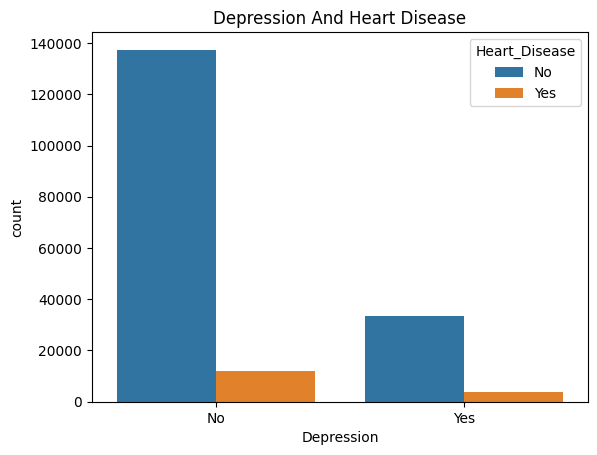

In [159]:
# Plot a graph between skin cancer and heart disease
sns.countplot(x = 'Depression', hue = 'Heart_Disease', data = df).set_title('Depression And Heart Disease')

#### Analysis of Depression and Heart Disease Relationship

* Patients without depression make up a larger share of total heart disease cases, mainly because they represent a larger portion of the dataset.
* However, the percentage of heart disease among individuals with depression (10.36%) is higher than that of individuals without depression (8.08%).

This suggests that individuals suffering from depression are slightly more likely to have heart disease compared to those without depression.
The association could be due to behavioral and physiological factors such as stress, inflammation, or lifestyle habits that often accompany depression, which can increase cardiovascular risk.

### Diabetes and Heart Disease

In [162]:
# Create a crosstab to get counts
diabetes_heart_counts = pd.crosstab(df['Diabetes'], df['Heart_Disease'])
print(diabetes_heart_counts)
# Convert counts to percentages within each checkup
diabetes_heart_percent = diabetes_heart_counts.div(diabetes_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
diabetes_heart_percent = diabetes_heart_percent.reset_index().melt(id_vars='Diabetes', var_name='Heart_Disease', value_name='Percentage')
print(diabetes_heart_percent)

Heart_Disease             No   Yes
Diabetes                          
Gestational Diabetes    1507    61
No                    145515  9833
Prediabetes             3824   515
Yes                    19922  5534
               Diabetes Heart_Disease  Percentage
0  Gestational Diabetes            No   96.109694
1                    No            No   93.670340
2           Prediabetes            No   88.130906
3                   Yes            No   78.260528
4  Gestational Diabetes           Yes    3.890306
5                    No           Yes    6.329660
6           Prediabetes           Yes   11.869094
7                   Yes           Yes   21.739472


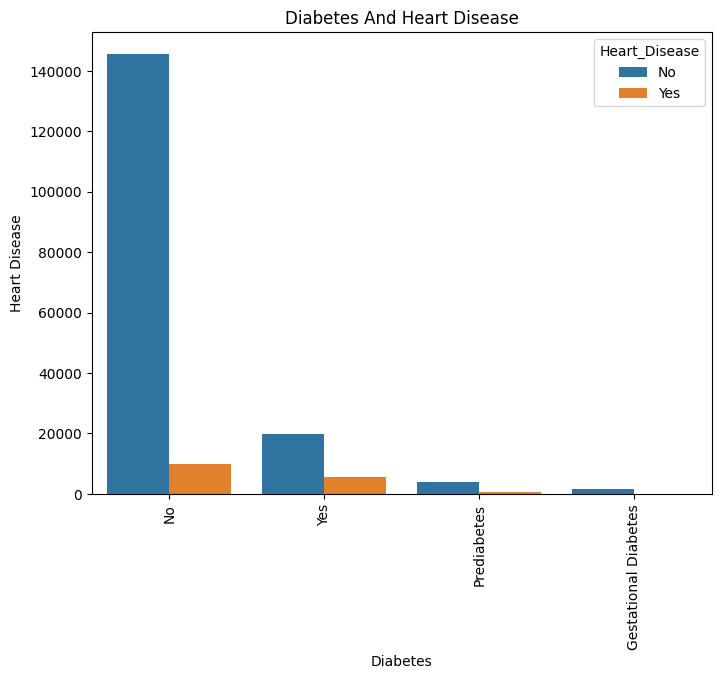

In [163]:
# Plot a graph between diabetes and heart disease
plt.figure(figsize = (8, 6))
sns.countplot(x = 'Diabetes', hue = 'Heart_Disease', data = df)
plt.title('Diabetes And Heart Disease')
plt.xlabel = ('Diabetes')
plt.ylabel('Heart Disease')
plt.xticks(rotation = 90)
plt.show()

#### Analysis of Diabetes and Heart Disease Relationship

The relationship between diabetes status and heart disease in the dataset is summarized below:

* Patients with diagnosed diabetes have the highest percentage (21.74%) of heart disease.
* Patients with prediabetes also show an elevated heart disease rate (11.87%) compared to those without diabetes.
* Individuals with gestational diabetes have the lowest association (3.89%), likely because it occurs temporarily during pregnancy.
* Those with no diabetes show a lower heart disease rate (6.33%) but still account for a large portion of total cases due to their higher population size.

The results indicate that the presence and severity of diabetes significantly increase the likelihood of heart disease.
While gestational and prediabetes have a smaller impact, chronic diabetes shows a strong association with cardiovascular risk, aligning with medical evidence that diabetes is a major risk factor for heart disease.

### Arthritis and Heart Disease

In [166]:
# Create a crosstab to get counts
arthritis_heart_counts = pd.crosstab(df['Arthritis'], df['Heart_Disease'])
print("Number of records with arthritis and heart disease:\n", arthritis_heart_counts)

# Convert counts to percentages within each checkup
arthritis_heart_percent = arthritis_heart_counts.div(arthritis_heart_counts.sum(axis=1), axis=0) * 100

# Reset index for plotting
arthritis_heart_percent = arthritis_heart_percent.reset_index().melt(id_vars='Arthritis', var_name='Heart_Disease', value_name='Percentage')
print(arthritis_heart_percent)

Number of records with arthritis and heart disease:
 Heart_Disease      No   Yes
Arthritis                  
No             119163  6904
Yes             51605  9039
  Arthritis Heart_Disease  Percentage
0        No            No   94.523547
1       Yes            No   85.094981
2        No           Yes    5.476453
3       Yes           Yes   14.905019


Text(0.5, 1.0, 'Arthritis And Heart Disease')

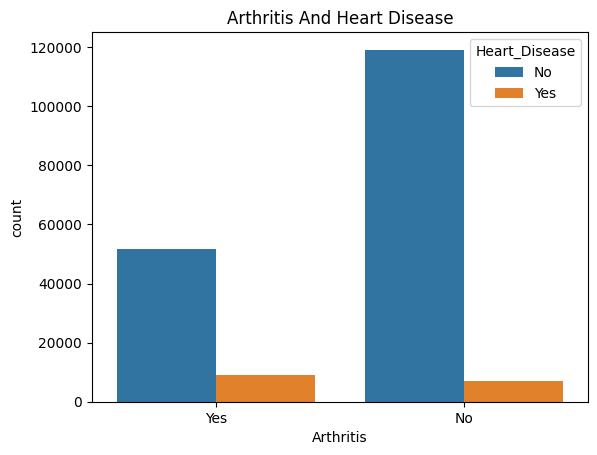

In [167]:
# Plot a graph between Arthritis and heart disease
sns.countplot(x = 'Arthritis', hue = 'Heart_Disease', data = df).set_title('Arthritis And Heart Disease')

#### Analysis of Arthritis and Heart Disease Relationship

* Patients with arthritis have a higher percentage of heart disease (14.91%) compared to those without arthritis (5.48%).
* On the other hand, patients without arthritis show a higher proportion of individuals without heart disease (94.52%).

This indicates that arthritis is associated with an increased likelihood of heart disease. The presence of arthritis — which often involves chronic inflammation — may contribute to cardiovascular risks. Patients with arthritis have higher cases of heart disease as compared to those without arthritis.

### Label Encoding the Categorical Variables

In [170]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

# Create label Encoding Object
le = LabelEncoder()
le

LabelEncoder()

In [171]:
# # Create a dictionary to store encoders and their mappings
label_mappings = {}

# List of categorical columns
cols = df.select_dtypes(include = ['object', 'category']).columns.tolist()

# Apply Label Encoding and store mappings
for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display mappings
for col, mapping in label_mappings.items():
    print(f"\n{col} Mapping:")
    for category, code in mapping.items():
        print(f"  {category} → {code}")


General_Health Mapping:
  Excellent → 0
  Fair → 1
  Good → 2
  Poor → 3
  Very Good → 4

Checkup Mapping:
  5 or more years ago → 0
  Never → 1
  Within the past 2 years → 2
  Within the past 5 years → 3
  Within the past year → 4

Exercise Mapping:
  No → 0
  Yes → 1

Heart_Disease Mapping:
  No → 0
  Yes → 1

Skin_Cancer Mapping:
  No → 0
  Yes → 1

Other_Cancer Mapping:
  No → 0
  Yes → 1

Depression Mapping:
  No → 0
  Yes → 1

Diabetes Mapping:
  Gestational Diabetes → 0
  No → 1
  Prediabetes → 2
  Yes → 3

Arthritis Mapping:
  No → 0
  Yes → 1

Sex Mapping:
  Female → 0
  Male → 1

Age_Category Mapping:
  18-24 → 0
  25-29 → 1
  30-34 → 2
  35-39 → 3
  40-44 → 4
  45-49 → 5
  50-54 → 6
  55-59 → 7
  60-64 → 8
  65-69 → 9
  70-74 → 10
  75-79 → 11
  80+ → 12

Smoking_History Mapping:
  No → 0
  Yes → 1


In [172]:
# Verify for label Encoding
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3,2,0,0,0,0,0,1,1,0,10,14.54,1,0.0,30.0,16.0,12.0
1,4,4,0,1,0,0,0,3,0,0,10,28.29,0,0.0,30.0,0.0,4.0
2,4,4,1,0,0,0,0,3,0,0,8,33.47,0,4.0,12.0,3.0,16.0
3,3,4,1,1,0,0,0,3,0,1,11,28.73,0,0.0,30.0,30.0,8.0
4,2,4,0,0,0,0,0,1,0,1,12,24.37,1,0.0,8.0,4.0,0.0


### Correlation Matrix

<Axes: >

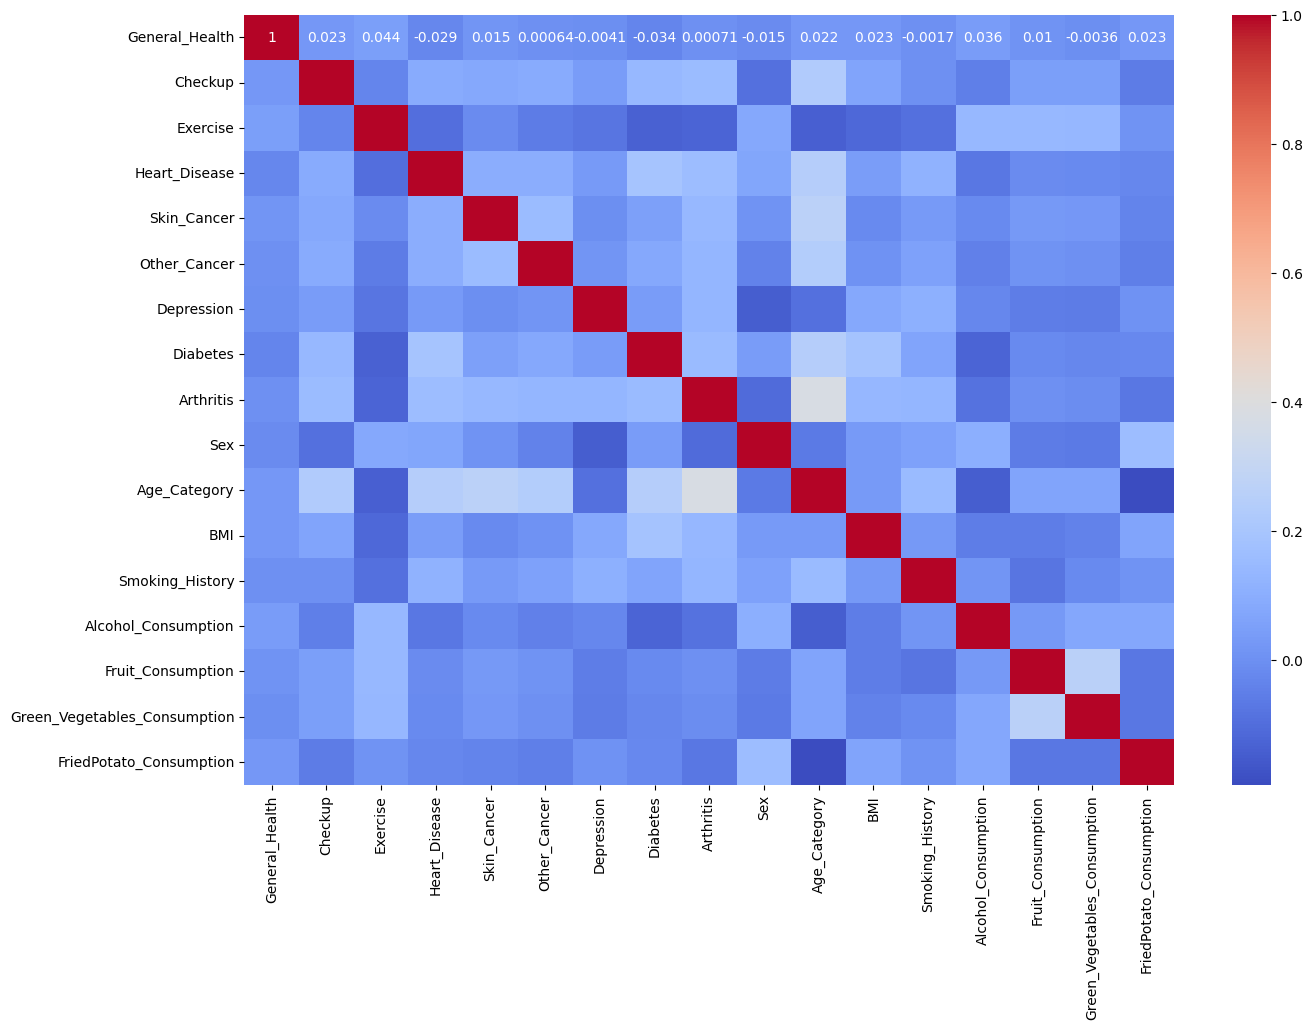

In [174]:
plt.figure(figsize = (15, 10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

There is no major coorelation among the variales.

### Train Test Split

In [177]:
# Import Train Test Split function 
from sklearn.model_selection import train_test_split

In [178]:
# Assign Independent and Target variables
X = df.drop(['Heart_Disease'], axis = 1)
y = df['Heart_Disease']

In [179]:
# Apply Train Test Function 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [180]:
# Verify the Shape of train and test dataset
print("X Train:", X_train.shape)
print("Y Train:", y_train.shape)
print("X Test:", X_test.shape)
print("Y Test:", y_test.shape)

X Train: (130697, 16)
Y Train: (130697,)
X Test: (56014, 16)
Y Test: (56014,)


### Standardization

In [182]:
# Import Standardizaton function 
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler Onbject
scaler = StandardScaler()
scaler

StandardScaler()

In [183]:
# Apply Scaler function to Training dataset
X_train = scaler.fit_transform(X_train)

# Apply transform into testing dataset
X_test = scaler.transform(X_test)

### Cardiovascular Disease Prediction

For predicting the cardiovascular disease, I have used the following classification models:

1. Decision Tree Classifier
2. Random Forest Classifier
3. Logistic Regression
   

### Decision Tree Classifier

In [186]:
# Import decision tree classifier function
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree Classifier Object
dtc = DecisionTreeClassifier()
dtc

DecisionTreeClassifier()

In [187]:
# Training the Model 
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [188]:
# Predict the training accuracy
print("Training Accuracy:", dtc.score(X_train, y_train))

Training Accuracy: 0.9999846974299333


In [189]:
# Predicting the test set results
dtc_pred = dtc.predict(X_test)

### Random Forest Classifier

In [191]:
# Import random forest classifier function
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest Classifier
rfc = RandomForestClassifier()
rfc

RandomForestClassifier()

In [192]:
# Training the Model 
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [193]:
# Predict the training accuracy
print("Training Accuracy:", rfc.score(X_train, y_train))

Training Accuracy: 0.9999387897197334


In [194]:
# Predicting the test set results
rfc_pred = rfc.predict(X_test)

### Logistic Regression

In [196]:
# Import logistic regression function 
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression object
lr = LogisticRegression()
lr

LogisticRegression()

In [197]:
# Training the Model 
lr.fit(X_train, y_train)

LogisticRegression()

In [198]:
# Predict the training accuracy
print("Training Accuracy:", lr.score(X_train, y_train))

Training Accuracy: 0.9138235766697017


In [199]:
# Predicting the test set results
lr_pred = lr.predict(X_test)

### Model Evaluation

#### **Confusion Matrix**

In [202]:
# Import Confusion Matrix
from sklearn.metrics import confusion_matrix

In [203]:
# Compute confusion matrices
cm_dtc = confusion_matrix(y_test, dtc_pred)
cm_rfc = confusion_matrix(y_test, rfc_pred)
cm_lr  = confusion_matrix(y_test, lr_pred)

# Print counts
print("Decision Tree Confusion Matrix:\n", cm_dtc)
print("\nRandom Forest Confusion Matrix:\n", cm_rfc)
print("\nLogistic Regression Confusion Matrix:\n", cm_lr)

Decision Tree Confusion Matrix:
 [[46926  4367]
 [ 3596  1125]]

Random Forest Confusion Matrix:
 [[50978   315]
 [ 4487   234]]

Logistic Regression Confusion Matrix:
 [[51124   169]
 [ 4573   148]]


Text(0.5, 1.0, 'Logistic')

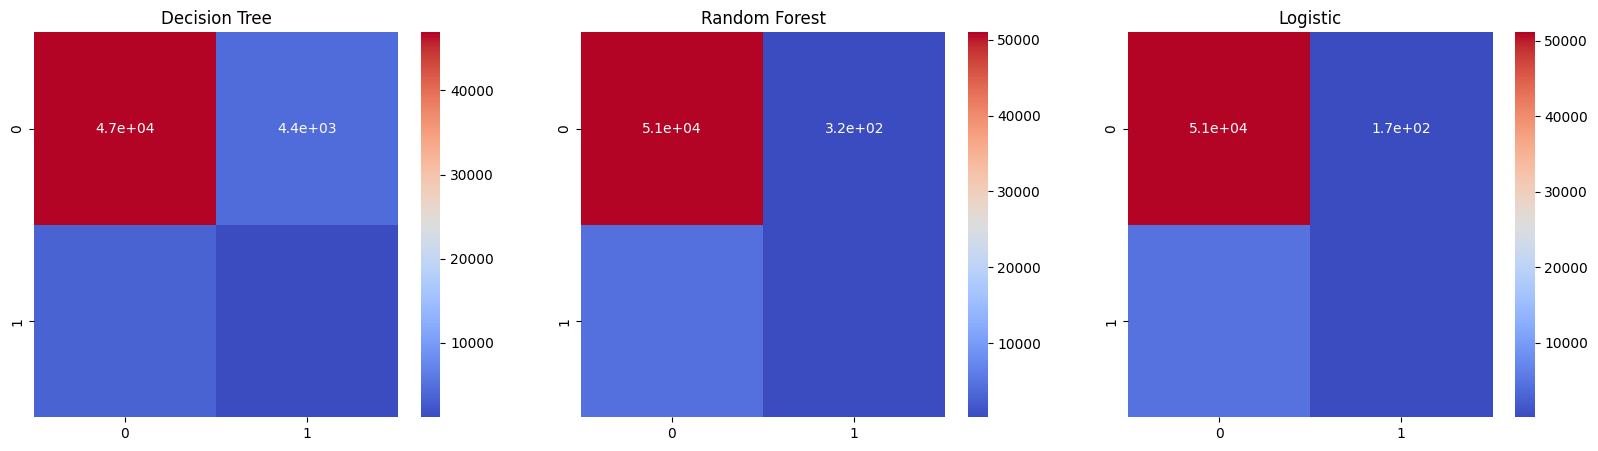

In [204]:
# Apply confusion matrix 
fig, ax = plt.subplots(1, 3, figsize = (20, 5))
sns.heatmap(confusion_matrix(y_test, dtc_pred), annot = True, cmap = 'coolwarm', ax = ax[0]).set_title('Decision Tree')
sns.heatmap(confusion_matrix(y_test, rfc_pred), annot = True, cmap = 'coolwarm', ax = ax[1]).set_title('Random Forest')
sns.heatmap(confusion_matrix(y_test, lr_pred), annot = True, cmap = 'coolwarm', ax = ax[2]).set_title('Logistic')

#### Confusion Matrix Analysis

1. **Decision Tree** - The Decision Tree model correctly classified 46,959 instances as negative (True Negatives) and 1,135 instances as positive (True Positives). It misclassified 4,334 negative instances as positive (False Positives) and 3,586 positive instances as negative (False Negatives). This shows that the model is better at identifying negative cases than positive ones.
2. **Random Forest** - The Random Forest model shows a higher number of correct classifications for negative cases, with 50,984 True Negatives and 254 True Positives. The False Positives are 309, and False Negatives are 4,467. While it significantly reduces misclassification of negatives compared to the Decision Tree, the model struggles more with correctly predicting positives.
3. **Logistic Regression** - The Logistic Regression model correctly predicted 51,124 negatives and 148 positives. It misclassified 169 negatives as positives and 4,573 positives as negatives. This model has the highest accuracy for negative predictions but the lowest True Positive count, indicating difficulty in detecting positive cases.

All three models perform well in identifying negative instances, but all struggle to correctly classify positive cases. Random Forest improves negative classification compared to Decision Tree, whereas Logistic Regression achieves the highest True Negative count but at the cost of very few True Positives. This suggests that the dataset is likely imbalanced towards negative cases, affecting positive prediction performance.

### Accuracy

1. **Accuracy Score** - The overall percentage of predictions the model got right.
2. **Precision Score** - Out of all the cases the model predicted as positive, how many were actually positive. (When the model says YES, how often is it really YES?)
3. **Recall Score** - Out of all the actual positive cases, how many did the model correctly identify. (Out of all the real YES cases, how many did the model catch?)
4. **F1 Score** - That balances precision and recall. (It’s useful when you want your model to be both correct when it says YES (precision) and catch as many actual YES cases as possible (recall).)

In [207]:
# Import accuracy function 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [208]:
# Decision Tree Model Evaluation
print('Decision Tree Evaluation:\n')
print('Accuracy Score:', accuracy_score(y_test, dtc_pred))
print('Precision Score:', precision_score(y_test, dtc_pred))
print('Recall Score:', recall_score(y_test, dtc_pred))
print('F1 Score:', f1_score(y_test, dtc_pred))

Decision Tree Evaluation:

Accuracy Score: 0.8578391116506587
Precision Score: 0.20484340859431902
Recall Score: 0.23829697098072442
F1 Score: 0.22030745128757465


In [209]:
# Random Forest Model Evaluation
print('Random Forest Evaluation:\n')
print('Accuracy Score:', accuracy_score(y_test, rfc_pred))
print('Precision Score:', precision_score(y_test, rfc_pred))
print('Recall Score:', recall_score(y_test, rfc_pred))
print('F1 Score:', f1_score(y_test, rfc_pred))

Random Forest Evaluation:

Accuracy Score: 0.9142714321419645
Precision Score: 0.4262295081967213
Recall Score: 0.04956576996399068
F1 Score: 0.0888045540796964


In [210]:
# logistic Regression Model 
print('Logictic Regression Evaluation:\n')
print('Accuracy Score:', accuracy_score(y_test, lr_pred))
print('Precision Score:', precision_score(y_test, lr_pred))
print('Recall Score:', recall_score(y_test, lr_pred))
print('F1 Score:', f1_score(y_test, lr_pred))

Logictic Regression Evaluation:

Accuracy Score: 0.9153425929231978
Precision Score: 0.4668769716088328
Recall Score: 0.0313492904045753
F1 Score: 0.058753473600635174


#### Accuracy Analysis

1. **Decision Tree Evaluation** 
   * Accuracy: 85.87% → The model correctly predicts the outcome for about 86% of all cases.
   * Precision: 20.53% → When the model predicts a positive case, it is correct only about 21% of the time.
   * Recall: 23.55% → The model detects about 24% of all actual positive cases.
   * F1 Score: 21.94% → Balancing precision and recall, the model performs moderately for positive cases.
The Decision Tree is fairly accurate overall, but it struggles to correctly identify positive cases, as shown by the low precision and recall. Lower accuracy, slightly better recall for positives.

2. **Random Forest Evaluation**
    * Accuracy: 91.42% → The model correctly predicts most cases.
    * Precision: 41.99% → When it predicts a positive case, it is correct about 42% of the time.
    * Recall: 4.72% → The model identifies only a very small fraction of actual positive cases.
    * F1 Score: 8.49% → Overall performance for positive cases is very low.
Random Forest improves overall accuracy and precision compared to Decision Tree, but it almost misses all positive cases, as seen in the extremely low recall and F1 score. High accuracy, higher precision, but almost misses positives.

3. **Logistic Regression Evaluation**
    * Accuracy: 91.53% → The model predicts most cases correctly.
    * Precision: 46.69% → When predicting a positive case, it is right nearly half the time.
    * Recall: 3.13% → The model detects very few of the actual positive cases.
    * F1 Score: 5.88% → The balance between precision and recall is very low.
Logistic Regression achieves the highest overall accuracy and slightly better precision than Random Forest, but it fails to capture most positive cases, indicated by the very low recall and F1 score. Highest accuracy and precision, but poorest at catching positives.

4. **Overall Insight** - All three models are good at predicting the majority class (negative cases), resulting in high overall accuracy. However, they struggle with detecting positive cases, especially Random Forest and Logistic Regression. This suggests the dataset is highly imbalanced, and special techniques like resampling, class weighting, or using models designed for imbalanced data may be needed to improve positive case detection.

* If your goal is overall correct predictions, Logistic Regression has the highest accuracy (91.53%), so it’s “best” by that metric.
* If your goal is detecting positive cases (like fraud, disease, etc.), Decision Tree is slightly better, since it has the highest recall (23.55%) and F1 score (21.94%).
* But for overall performance, Logistic Regression or Random Forest is better.

### Feature Importance

In [213]:
# Train Random Forest
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X, y)

RandomForestClassifier(random_state=42)

In [214]:
# Get feature importance
importance = pd.Series(rfc.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Print feature importance
print(importance)

BMI                             0.240114
Green_Vegetables_Consumption    0.122220
FriedPotato_Consumption         0.109867
Fruit_Consumption               0.107901
Age_Category                    0.102644
General_Health                  0.066676
Alcohol_Consumption             0.064190
Diabetes                        0.033122
Arthritis                       0.020848
Depression                      0.020793
Exercise                        0.020522
Other_Cancer                    0.020372
Sex                             0.019956
Checkup                         0.017330
Skin_Cancer                     0.017085
Smoking_History                 0.016360
dtype: float64


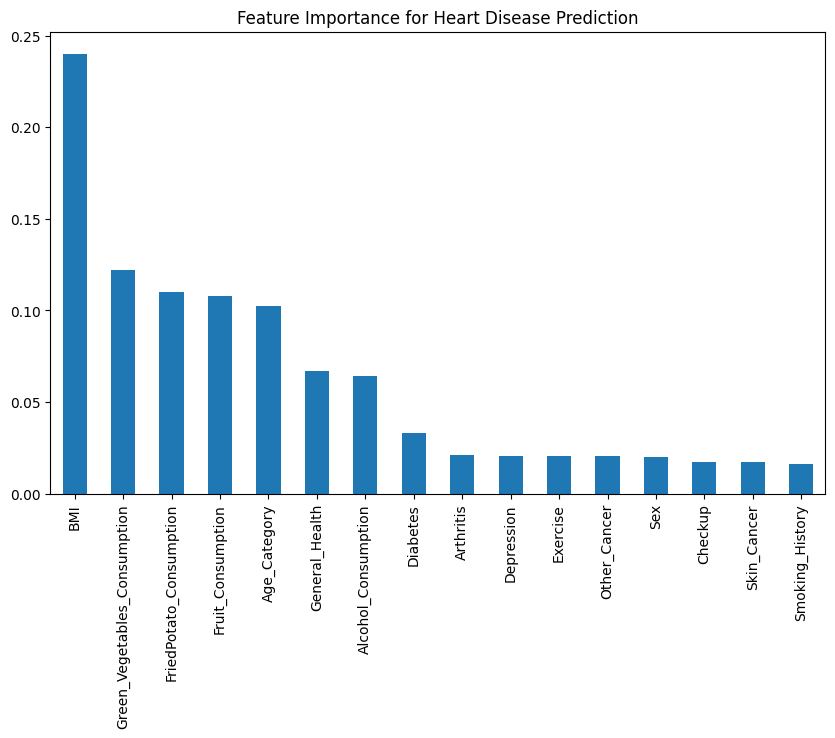

In [215]:
# Optional: Plot feature importance
plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title("Feature Importance for Heart Disease Prediction")
plt.show()

* Top predictors - BMI, diet (vegetables, fruit, fried potatoes), and age — these features account for more than 70% of the model’s predictive power.
* Moderate impact - General health and alcohol consumption.
* Low impact - Previous medical conditions (diabetes, arthritis, depression, cancer), sex, checkups, exercise, and smoking history contribute very little to predicting heart disease in this dataset.

Lifestyle factors, BMI, age, and diet are the strongest indicators of heart disease risk in this dataset.

#### Conclusion 

From the exploratory data analysis and feature importance results, it was observed that the risk of cardiovascular disease increases with age, particularly in individuals above 55 years, with the highest prevalence among those over 80. Higher BMI is strongly associated with greater risk. Dietary habits also play a significant role: patients who consume more fruits and green vegetables are less likely to develop cardiovascular disease, whereas those who consume fried potatoes are at higher risk. Smoking history and exercise appear to have minimal impact in this dataset. Similarly, previous medical conditions such as cancer, arthritis, diabetes, or depression do not appear to significantly affect cardiovascular disease risk.